In [3]:
import os
import glob
import pandas as pd
import re

# --- CONFIGURATION ---x
BASE_PATH = "/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/"

# This pattern looks into BASE_PATH/Participant/eeg/ and finds all CSVs recursively
# Structure: derived/<participant>/eeg/**/*.csv
eeg_files = glob.glob(os.path.join(BASE_PATH, "*", "eeg", "**", "*.csv"), recursive=True)

print(f"Total EEG files found: {len(eeg_files)}")

if len(eeg_files) > 0:
    print("\n--- SAMPLE PATHS FOUND ---")
    for p in eeg_files[:3]:
        print(f"Path: {p}")
        # Parse logic check
        rel = os.path.relpath(p, BASE_PATH).split(os.sep)
        # rel[0] should be Participant Name
        print(f"  Parsed -> Participant: {rel[0]}, Filename: {os.path.basename(p)}")
else:
    print("ERROR: Still no files found. Please run 'ls -R /Users/sgomasta/Desktop/Tech Neck Coding/derived/' in your terminal to verify folder names.")

Total EEG files found: 143

--- SAMPLE PATHS FOUND ---
Path: /Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/eeg/numerical/Abhay_d1_rain.csv
  Parsed -> Participant: Abhay, Filename: Abhay_d1_rain.csv
Path: /Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/eeg/numerical/Abhay_d3_rain.csv
  Parsed -> Participant: Abhay, Filename: Abhay_d3_rain.csv
Path: /Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/Abhay/eeg/numerical/Abhay_d2_rain.csv
  Parsed -> Participant: Abhay, Filename: Abhay_d2_rain.csv


<h1> Signal Quality </h1>

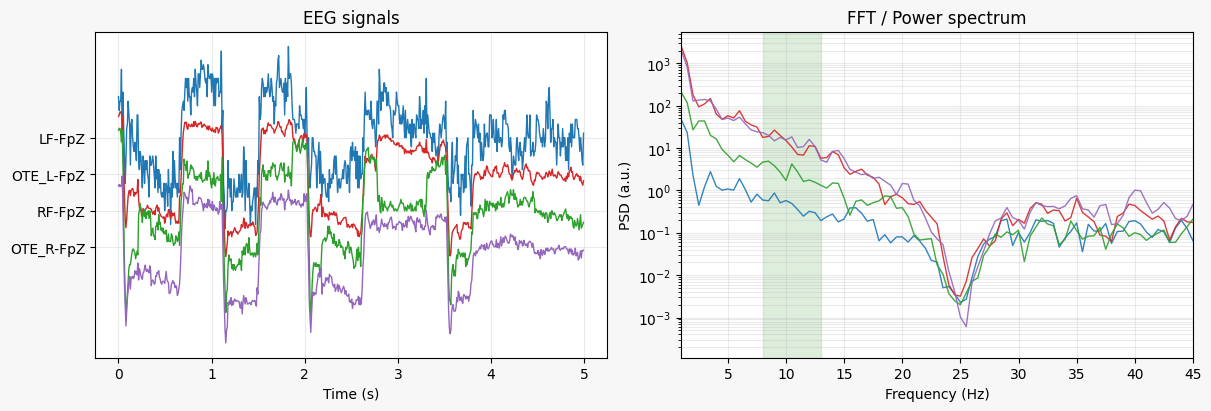

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Your preferred colors
ALPHA_COLOR = "#7fbf7b"   # alpha band highlight
BG_COLOR = "#f7f7f7"      # light background

def _find_channel_idx(ch_names, target):
    """Exact match first, otherwise case-insensitive match."""
    if target in ch_names:
        return ch_names.index(target)
    lower = [c.lower() for c in ch_names]
    t = target.lower()
    if t in lower:
        return lower.index(t)
    return None

def plot_eeg_timeseries_and_psd(
    df_eeg,
    ppt_name="Abhay",
    row_selector=None,      # optional: pick a specific row/session
    start_sec=0.0,
    win_sec=5.0,
    alpha_band=(8, 13),
    fmax=45,
):
    """
    Plots a 2-panel inspection figure:
      (1) EEG time series (stacked, z-normalized)
      (2) PSD (Welch) with alpha band shaded

    Expects df_eeg rows with:
      - participant
      - data: numpy array [N, C]
      - fs: sampling rate
      - ch_names: list of channel names (must include 4 channels below)
      - optional: task, posture (for title)
    """

    subset = df_eeg[df_eeg["participant"] == ppt_name]
    if subset.empty:
        print(f"No data for participant: {ppt_name}")
        return

    session = subset.iloc[0] if row_selector is None else None
    if row_selector is not None:
        rows = [r for _, r in subset.iterrows() if row_selector(r)]
        if not rows:
            print(f"No session matched row_selector for {ppt_name}")
            return
        session = rows[0]

    data = session["data"]
    fs = float(session["fs"])
    ch_names = list(session["ch_names"])

    # --- Window slice ---
    n0 = max(0, int(start_sec * fs))
    n1 = min(data.shape[0], int((start_sec + win_sec) * fs))
    if n1 - n0 < int(1 * fs):
        print("Window too small. Increase win_sec or adjust start_sec.")
        return

    seg = data[n0:n1, :]
    t = np.arange(seg.shape[0]) / fs

    # --- Exact 4-channel selection ---
    wanted = ["LF-FpZ", "OTE_L-FpZ", "RF-FpZ", "OTE_R-FpZ"]
    idxs = [_find_channel_idx(ch_names, w) for w in wanted]

    if any(i is None for i in idxs):
        print("Could not find all required channels.")
        print("Required:", wanted)
        print("Found ch_names:", ch_names)
        return

    eeg = seg[:, idxs]
    labels = [ch_names[i] for i in idxs]

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    fig.patch.set_facecolor(BG_COLOR)

    # Panel 1: EEG time series (stacked)
    ax = axes[0]
    ax.set_title("EEG signals", fontsize=12)

    colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]  # blue/red/green/purple
    offsets = np.array([3, 2, 1, 0], dtype=float)

    for i in range(eeg.shape[1]):
        x = eeg[:, i].astype(float)
        x = (x - np.median(x)) / (np.std(x) + 1e-8)  # robust-ish normalization
        ax.plot(t, x + offsets[i], color=colors[i], lw=1.0)

    ax.set_xlabel("Time (s)")
    ax.set_yticks(offsets)
    ax.set_yticklabels(labels)
    ax.grid(True, alpha=0.25)

    # Panel 2: PSD (Welch)
    ax = axes[1]
    ax.set_title("FFT / Power spectrum", fontsize=12)

    for i in range(eeg.shape[1]):
        freqs, psd = welch(
            eeg[:, i].astype(float),
            fs=fs,
            nperseg=min(int(fs * 2), eeg.shape[0]),
        )
        ax.semilogy(freqs, psd, color=colors[i], lw=1.0, alpha=0.9)

    ax.axvspan(alpha_band[0], alpha_band[1], color=ALPHA_COLOR, alpha=0.25)
    ax.set_xlim(1, fmax)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (a.u.)")
    ax.grid(True, which="both", alpha=0.25)

    # Figure title
    task = session["task"] if "task" in session else "unknown_task"
    posture = session["posture"] if "posture" in session else "unknown_posture"
    # fig.suptitle(
    #     f"{ppt_name} | {task} | {posture} | window: {start_sec:.1f}-{start_sec+win_sec:.1f}s",
    #     fontsize=12
    # )

    plt.show()


# Example:
plot_eeg_timeseries_and_psd(df_eeg, ppt_name="Abhay", start_sec=10, win_sec=5)


<h1>EEG ALpha Peak FFT analysis <h1>

✓ Saved PDF: /Users/sgomasta/Desktop/Tech Neck Coding/Plots/eeg_fft_Ankur_rest_d1.pdf
✓ Saved PNG: /Users/sgomasta/Desktop/Tech Neck Coding/Plots/eeg_fft_Ankur_rest_d1.png


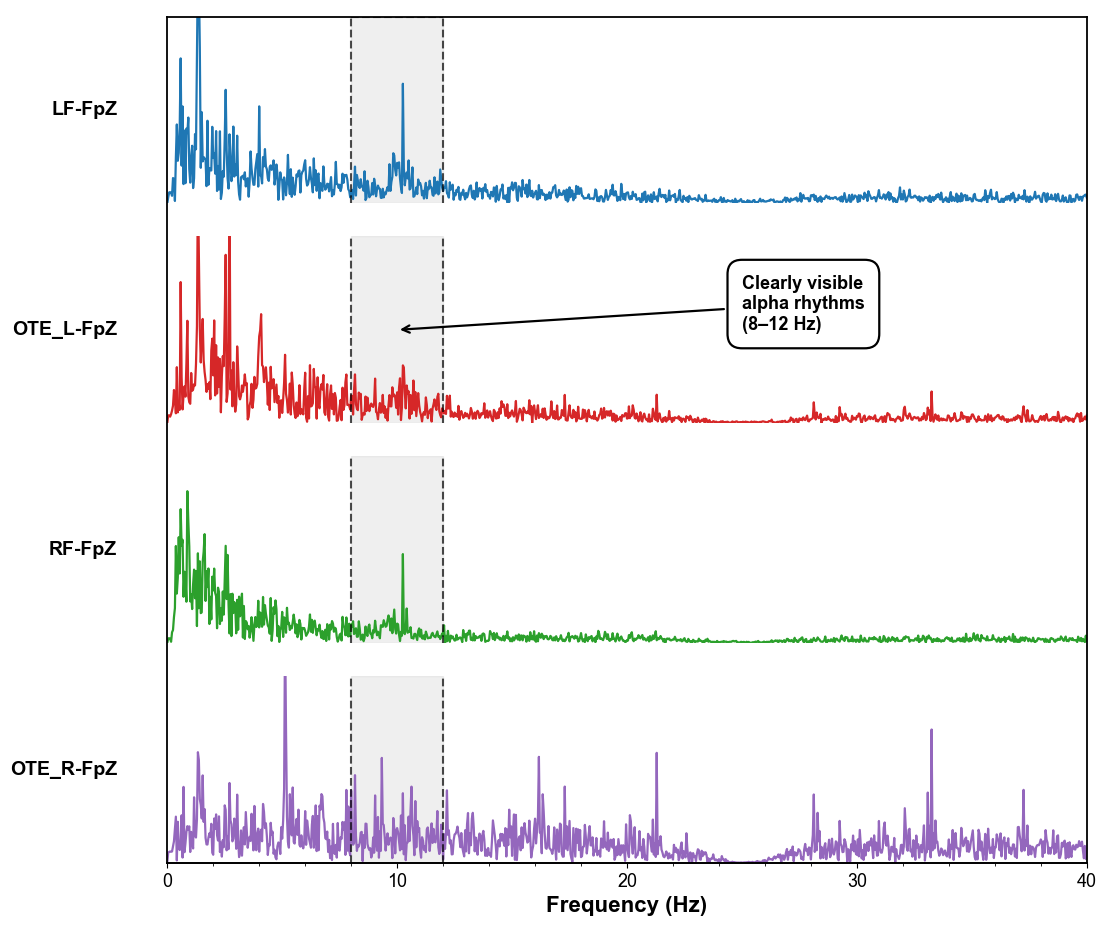

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
import matplotlib.ticker as ticker
import os

def plot_eeg_fft_publication(df_eeg, 
                             ppt_name="Ankur",
                             save_dir="~/Desktop/Tech Neck Coding/Plots",
                             save_pdf=True,
                             save_png=True,
                             dpi=300):
    """
    Publication-quality EEG FFT plot.
    Boxed figure, larger fonts, no title (caption in LaTeX).
    """

    # -----------------------------
    # Publication-quality fonts (INCREASED)
    # -----------------------------
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 22,
        'axes.labelsize': 16,
        'axes.titlesize': 16,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'axes.linewidth': 1.2,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.facecolor': 'white',
        'savefig.edgecolor': 'white'
    })

    # -----------------------------
    # 1. Select Rest-D1 Data
    # -----------------------------
    subset = df_eeg[
        (df_eeg["participant"] == ppt_name) &
        (df_eeg["task"] == "rest") &
        (df_eeg["posture"] == "d1")
    ]

    if subset.empty:
        print(f"No rest-d1 data found for {ppt_name}")
        return

    session = subset.iloc[0]
    data, fs = session["data"], float(session["fs"])

    ch_labels = ["LF-FpZ", "OTE_L-FpZ", "RF-FpZ", "OTE_R-FpZ"]
    colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]

    # -----------------------------
    # 20s offset for stability
    # -----------------------------
    process_data = data[int(20 * fs):, :4]
    alpha_start, alpha_end = 8, 12

    # -----------------------------
    # 2. Setup Plot (FIGURE SIZE INCREASED)
    # -----------------------------
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    plt.subplots_adjust(hspace=0, left=0.18, right=0.95, bottom=0.14)

    for i, ax in enumerate(axes):
        # FFT
        sig = process_data[:, i] - np.mean(process_data[:, i])
        N = len(sig)
        mag = np.abs(rfft(sig)) / N
        freqs = rfftfreq(N, 1 / fs)

        mask = (freqs >= 0) & (freqs <= 40)
        ax.plot(freqs[mask], mag[mask], color=colors[i], lw=1.6)

        # --- Alpha band box ---
        ax.axvspan(alpha_start, alpha_end, color="gray", alpha=0.12, zorder=0)
        ax.axvline(alpha_start, color="black", linestyle="--", lw=1.5, alpha=0.7)
        ax.axvline(alpha_end, color="black", linestyle="--", lw=1.5, alpha=0.7)

        if i == 0:
            y_limit = np.percentile(mag[mask], 98) * 2.6
            ax.set_ylim(0, y_limit)
            ax.hlines(
                y_limit,
                alpha_start,
                alpha_end,
                colors="black",
                linestyles="--",
                lw=1.5,
                alpha=0.7
            )
        else:
            ax.set_ylim(0, np.percentile(mag[mask], 98) * 2.6)

        # Formatting
        ax.set_yticks([])
        ax.set_ylabel(
            ch_labels[i],
            rotation=0,
            ha="right",
            va="center",
            fontweight="bold",
            fontsize=14,
            labelpad=36
        )

        ax.spines[['top', 'right', 'left']].set_visible(False)

        if i < 3:
            ax.spines['bottom'].set_visible(False)
            ax.tick_params(axis='x', which='both', bottom=False)

    # -----------------------------
    # 3. X-axis
    # -----------------------------
    axes[-1].set_xlim(0, 40)
    axes[-1].set_xlabel("Frequency (Hz)", fontsize=16, fontweight='bold')
    axes[-1].xaxis.set_major_locator(ticker.MultipleLocator(10))
    axes[-1].xaxis.set_minor_locator(ticker.MultipleLocator(2))
    axes[-1].spines['bottom'].set_visible(True)
    axes[-1].spines['bottom'].set_linewidth(1.2)

    # -----------------------------
    # 4. Alpha annotation (unchanged)
    # -----------------------------
    axes[1].annotate(
        "Clearly visible\nalpha rhythms\n(8–12 Hz)",
        xy=(10, axes[1].get_ylim()[1] * 0.5),
        xytext=(25, axes[1].get_ylim()[1] * 0.5),
        arrowprops=dict(arrowstyle="->", lw=1.6),
        bbox=dict(boxstyle="round,pad=0.8", fc="white", ec="black", lw=1.6),
        fontsize=13,
        fontweight="bold"
    )

    # -----------------------------
    # OUTER BOX AROUND WHOLE FIGURE
    # -----------------------------
    box_ax = fig.add_subplot(111, frameon=True)
    box_ax.patch.set_alpha(0)
    box_ax.tick_params(labelcolor='none', top=False, bottom=False,
                       left=False, right=False)
    for spine in box_ax.spines.values():
        spine.set_linewidth(1.3)

    plt.tight_layout()

    # -----------------------------
    # Save
    # -----------------------------
    out_dir = os.path.expanduser(save_dir)
    os.makedirs(out_dir, exist_ok=True)

    base = f"eeg_fft_{ppt_name}_rest_d1"
    pdf_path = os.path.join(out_dir, base + ".pdf")
    png_path = os.path.join(out_dir, base + ".png")

    if save_pdf:
        plt.savefig(pdf_path, bbox_inches="tight", facecolor='white', edgecolor='none')
        print(f"✓ Saved PDF: {pdf_path}")
    if save_png:
        plt.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor='white', edgecolor='none')
        print(f"✓ Saved PNG: {png_path}")

    plt.show()

    # return {
    #     "saved_pdf": pdf_path if save_pdf else None,
    #     "saved_png": png_path if save_png else None
    # }

# ============================================================
# EXECUTION
# ============================================================
result = plot_eeg_fft_publication(
    df_eeg,
    ppt_name="Ankur",
    save_dir="~/Desktop/Tech Neck Coding/Plots",
    save_pdf=True,
    save_png=True,
    dpi=300
)


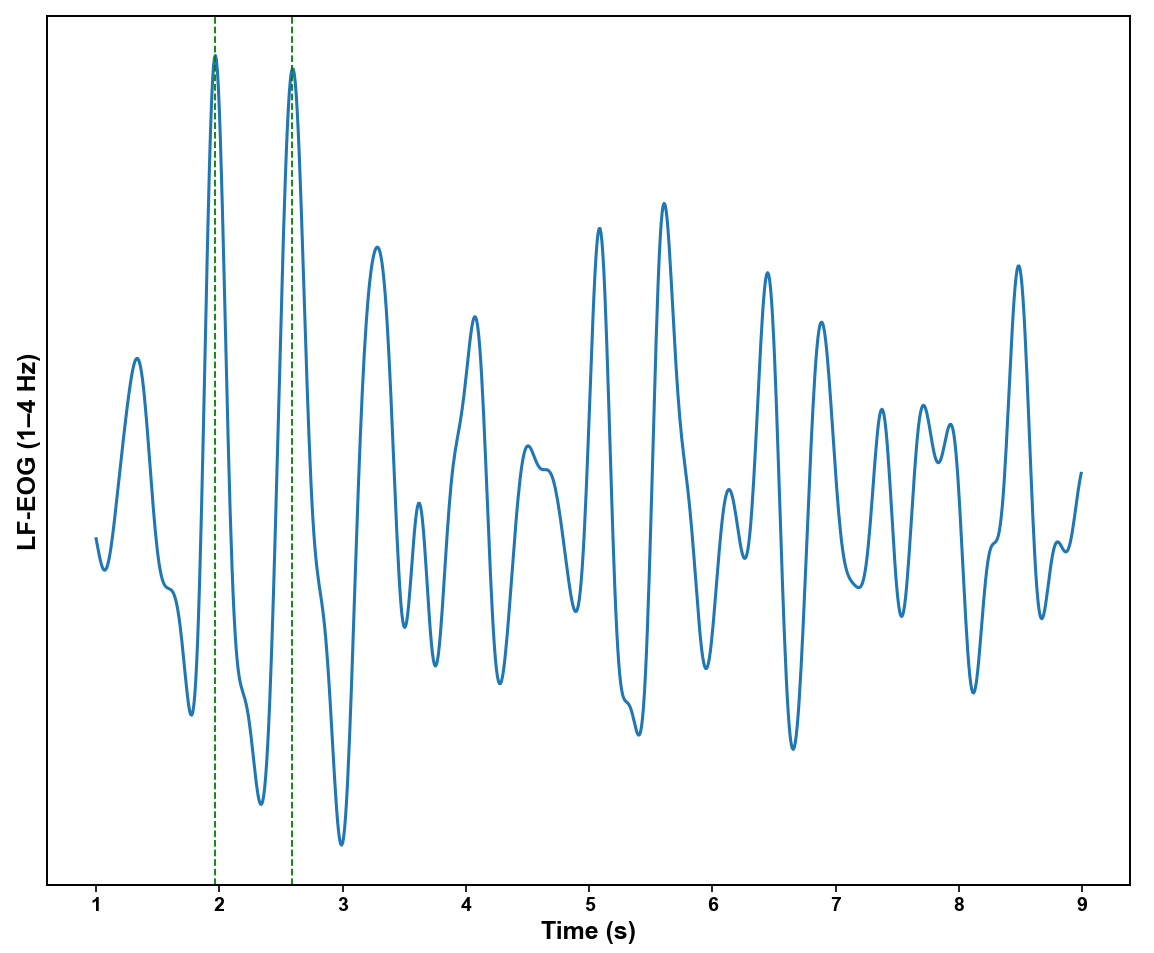

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, detrend

# ============================================================
# 1) FILTERING (EDFbrowser-like): Notch (25, 50) + Bandpass (1–4 Hz)
# ============================================================
def notch_filter(sig, fs, f0, Q=30):
    w0 = f0 / (fs / 2.0)
    b, a = iirnotch(w0, Q)
    return filtfilt(b, a, sig)

def bandpass(sig, fs, low=1.0, high=4.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, sig)

def eog_preprocess(raw, fs, do_notch=True, notch_freqs=(25.0, 50.0), Q=30):
    x = detrend(raw, type="constant")  # remove DC
    if do_notch:
        for f0 in notch_freqs:
            if f0 < fs / 2.0:
                x = notch_filter(x, fs, f0, Q=Q)
    x = bandpass(x, fs, low=1.0, high=4.0, order=4)
    return x

# ============================================================
# 2) MERGE CLOSE PEAKS INTO ONE BLINK EVENT (biphasic blink shape)
# ============================================================
def merge_close_peaks(peaks, heights, fs, merge_ms=180):
    if len(peaks) == 0:
        return np.array([], dtype=int)

    merge_samp = int((merge_ms / 1000.0) * fs)
    merged = []

    i = 0
    while i < len(peaks):
        best = i
        j = i + 1
        while j < len(peaks) and (peaks[j] - peaks[i]) <= merge_samp:
            if heights[j] > heights[best]:
                best = j
            j += 1
        merged.append(peaks[best])
        i = j

    return np.array(merged, dtype=int)

# ============================================================
# 3) BLINK DETECTION ON LF-EOG (polarity-invariant) + merge
# ============================================================
def detect_blinks_lf(lf_eog, fs,
                     z_thresh=2.5,
                     min_distance_ms=60,
                     min_width_ms=30,
                     max_width_ms=300,
                     prominence=0.6,
                     merge_ms=180):
    mu = np.mean(lf_eog)
    sd = np.std(lf_eog) + 1e-8
    z = (lf_eog - mu) / sd
    az = np.abs(z)

    min_dist = int((min_distance_ms / 1000.0) * fs)
    min_w = int((min_width_ms / 1000.0) * fs)
    max_w = int((max_width_ms / 1000.0) * fs)

    peaks, props = find_peaks(
        az,
        height=z_thresh,
        distance=min_dist,
        prominence=prominence,
        width=(min_w, max_w)
    )

    heights = props.get("peak_heights", np.array([]))
    peaks_merged = merge_close_peaks(peaks, heights, fs, merge_ms=merge_ms)

    return peaks_merged

# ============================================================
# 4) PLOT LF ONLY + SAVE (paper style: white bg, boxed, bold)
# ============================================================
def _make_white_box_style(fig, ax):
    """White background, boxed axes, NO grid, bold ticks."""
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
    ax.tick_params(direction="out", length=5, width=1.2, labelsize=14)
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontweight("bold")

def plot_lf_eog_blinks(df_eeg,
                       ppt_name="Ankur",
                       task="stroop",
                       duration_sec=8,
                       start_sec=12.9,
                       lf_col=0,
                       z_thresh=2.5,
                       prominence=0.6,
                       merge_ms=180,
                       save_dir="~/Desktop/Tech Neck Coding/Plots",
                       save_pdf=True,
                       save_png=True,
                       dpi=300):
    """
    - Uses LF only
    - Filters: notch 25/50 + bandpass 1-4 Hz
    - Blink detection: peaks on |z| then merge close peaks into one blink
    - Plot style: no y ticks, bold labels, boxed figure, no grid
    - X-axis starts at 1 (relative time)
    - Saves figure to save_dir
    """

    # -----------------------------
    # Global paper style (MATCH your other plots)
    # -----------------------------
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 22,
        "axes.labelsize": 18,
        "axes.labelweight": "bold",
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "axes.linewidth": 1.2,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white"
    })

    # -----------------------------
    # Select data
    # -----------------------------
    subset = df_eeg[(df_eeg["participant"] == ppt_name) & (df_eeg["task"] == task)]
    if subset.empty:
        print(f"No {task} data found for {ppt_name}")
        return None

    session = subset.iloc[0]
    data = session["data"]
    fs = float(session["fs"])

    # Segment
    n0 = int(start_sec * fs)
    n1 = min(n0 + int(duration_sec * fs), data.shape[0])
    if n1 <= n0:
        print("Error: start_sec is beyond the available signal length.")
        return None

    seg = data[n0:n1, :]
    t = np.arange(seg.shape[0]) / fs + 1.0  # relative axis starts at 1

    # LF raw channel
    lf_raw = seg[:, lf_col]

    # Preprocess LF as EOG
    lf_eog = eog_preprocess(lf_raw, fs, do_notch=True, notch_freqs=(25.0, 50.0), Q=30)

    # Detect blinks (merged)
    peaks_merged = detect_blinks_lf(
        lf_eog, fs,
        z_thresh=z_thresh,
        min_distance_ms=60,
        min_width_ms=30,
        max_width_ms=300,
        prominence=prominence,
        merge_ms=merge_ms
    )

    blink_times_rel = (peaks_merged / fs) + 1.0
    blink_times_abs = (peaks_merged / fs) + start_sec

    # -----------------------------
    # Plot (MATCH your 12x8 style)
    # -----------------------------
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.plot(t, lf_eog, lw=2.2)

    for bt in blink_times_rel:
        ax.axvline(bt, color="green", linestyle="--", linewidth=1.3)

    # No y ticks, keep y label
    ax.set_yticks([])
    ax.set_ylabel("LF-EOG (1–4 Hz)", fontweight="bold")
    ax.set_xlabel("Time (s)", fontweight="bold")

    # No grid
    ax.grid(False)

    # Box + bold ticks
    _make_white_box_style(fig, ax)

    # Also add an OUTER figure frame (like your other multi-panel figures)
    box_ax = fig.add_subplot(111, frameon=True)
    box_ax.patch.set_alpha(0)
    box_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    for spine in box_ax.spines.values():
        spine.set_linewidth(1.3)

    fig.tight_layout()

    # -----------------------------
    # Save
    # -----------------------------
    out_dir = os.path.expanduser(save_dir)
    os.makedirs(out_dir, exist_ok=True)

    base = f"eog_lf_{ppt_name}_{task}_{start_sec:.1f}-{start_sec+duration_sec:.1f}s"
    pdf_path = os.path.join(out_dir, base + ".pdf")
    png_path = os.path.join(out_dir, base + ".png")

    if save_pdf:
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white", edgecolor="none")
    if save_png:
        fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white", edgecolor="none")

    plt.show()
    plt.close(fig)

    return {
        "blink_times_abs_sec": blink_times_abs,
        "blink_times_rel_sec": blink_times_rel,
        "saved_pdf": pdf_path if save_pdf else None,
        "saved_png": png_path if save_png else None
    }

# ============================================================
# EXECUTION
# ============================================================
result = plot_lf_eog_blinks(
    df_eeg,
    ppt_name="Ankur",
    task="stroop",
    duration_sec=8,
    start_sec=12.9,
    lf_col=0,
    z_thresh=2.5,
    prominence=0.6,
    merge_ms=180,
    save_dir="~/Desktop/Tech Neck Coding/Plots",
    save_pdf=True,
    save_png=True,
    dpi=300
)

# if result is not None:
#     print("Saved PDF:", result["saved_pdf"])
#     print("Saved PNG:", result["saved_png"])


<h1>Neural Biomarker </h1>

Extracting Neural Features and Fitting Statistics...

--- Linear Mixed Model: PeriodicAlpha (C(Condition) * C(Posture)) ---
                        Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         PeriodicAlpha
No. Observations:           143             Method:                     REML         
No. Groups:                 24              Scale:                      0.1255       
Min. group size:            5               Log-Likelihood:             -78.6791     
Max. group size:            6               Converged:                  Yes          
Mean group size:            6.0                                                      
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                               

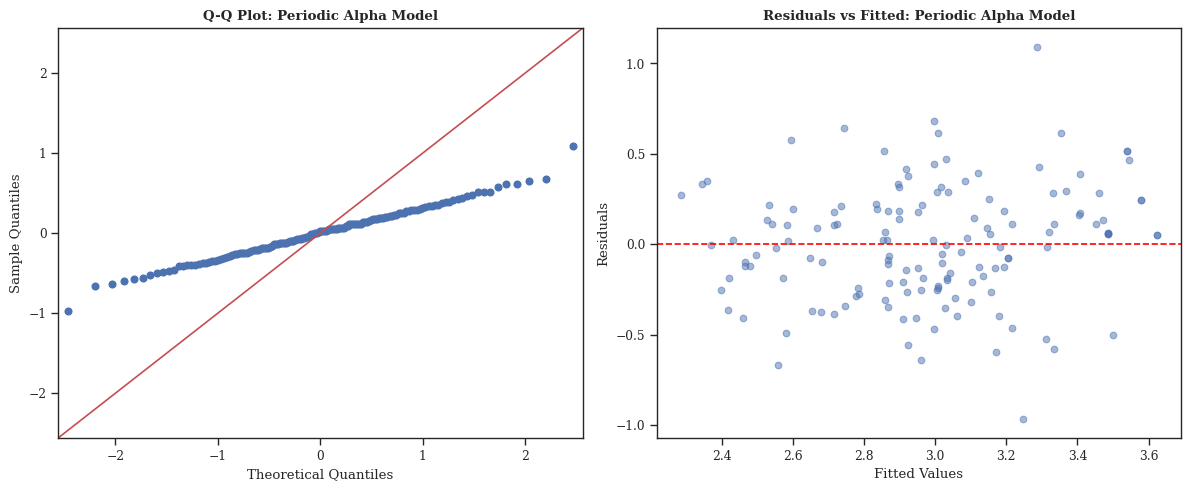

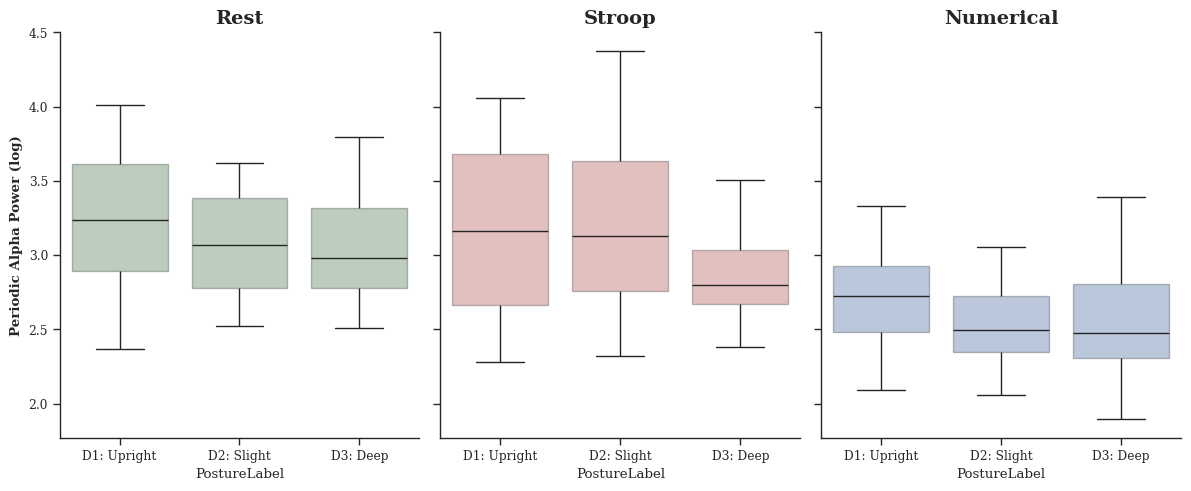

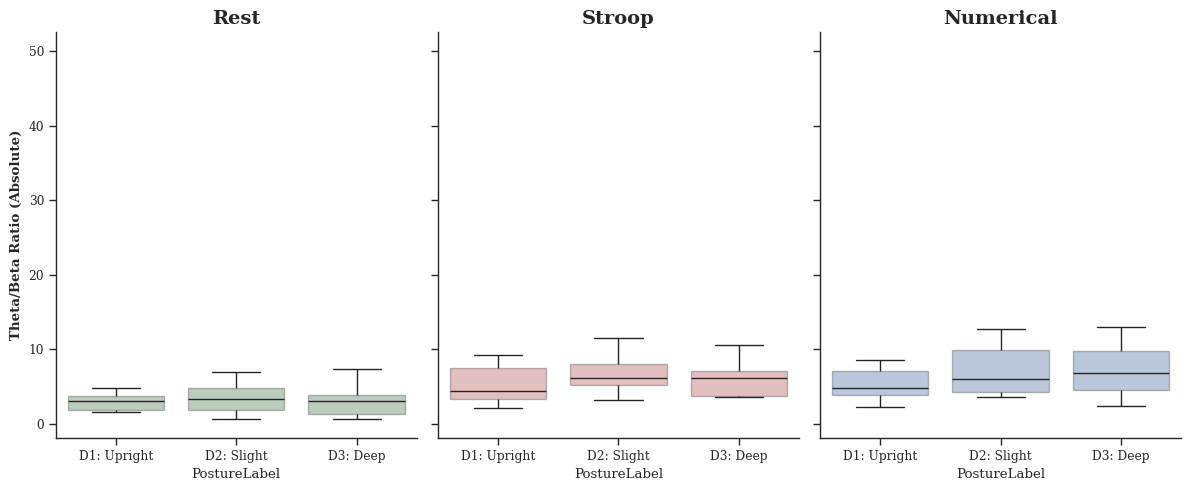

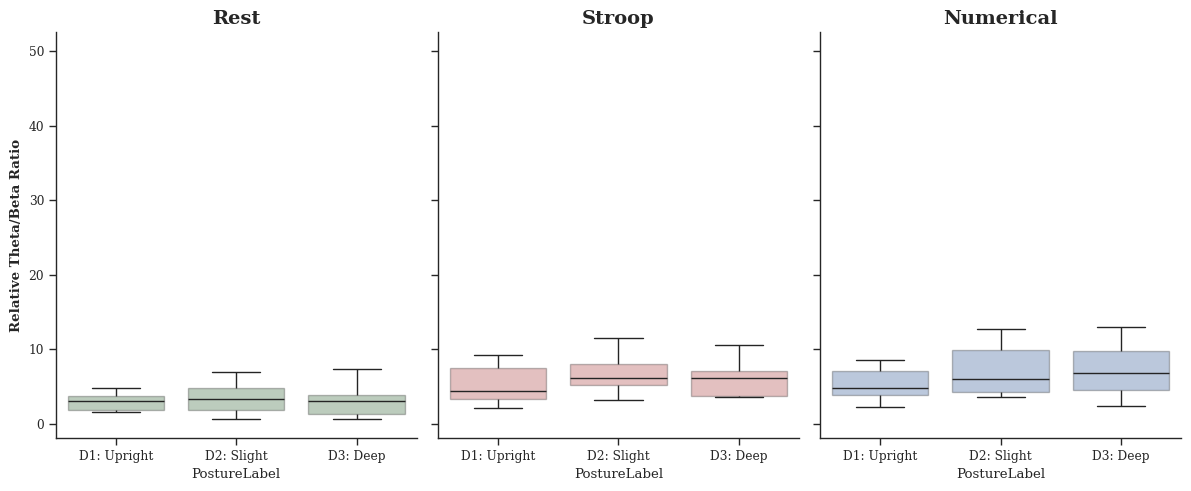

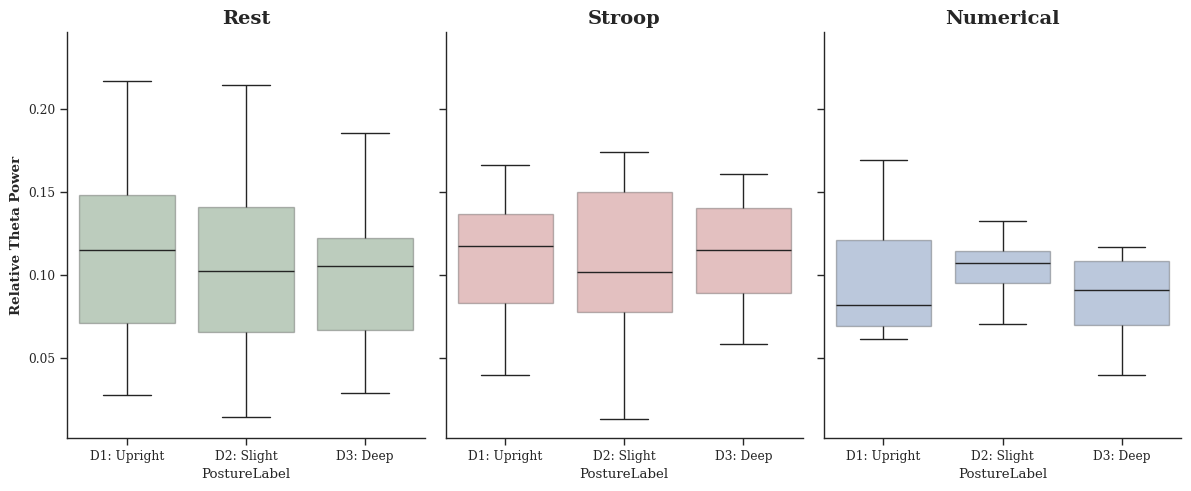

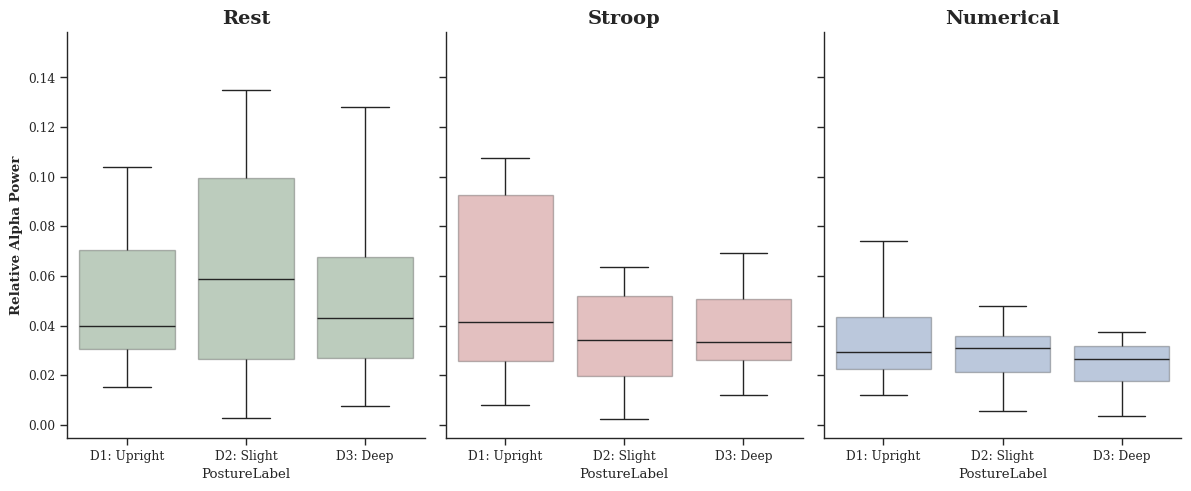

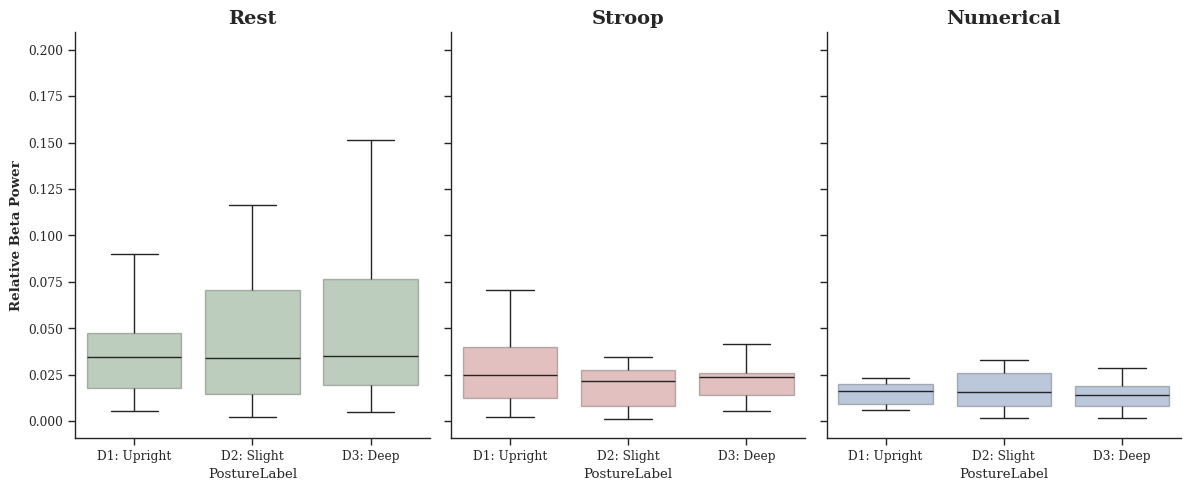

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy.integrate import simps
from specparam import SpectralModel
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")

# =========================================================
# 1. CORE CONFIGURATION
# =========================================================
FS = 125
TRIM_SEC = 15.0
FREQ_RANGE = [1, 30]
ALPHA_BAND, THETA_BAND, BETA_BAND = [8, 13], [4, 7], [13, 30]
WIN_SAMPLES = int(5 * FS)
OVERLAP = WIN_SAMPLES // 2

def select_frontal_channels(ch_names):
    priority = ["OTE_L-FpZ", "OTE_R-FpZ", "LF-FpZ", "RF-FpZ"]
    idxs = [ch_names.index(n) for n in priority if n in ch_names]
    return idxs[:4] if idxs else [0, 1, 2, 3]

# =========================================================
# 2. FEATURE EXTRACTION (SLIDING WINDOW)
# =========================================================
def extract_eeg_features(row):
    data, ch_names = row["data"], list(row["ch_names"])
    trim = int(TRIM_SEC * FS)
    if data.shape[0] <= 2 * trim: return None
    
    seg = data[trim:-trim, :]
    ch_idxs = select_frontal_channels(ch_names)
    pa_list, t_list, b_list, a_list, total_list = [], [], [], [], []

    for ci in ch_idxs:
        sig = seg[:, ci]
        freqs, psd = welch(sig, fs=FS, nperseg=WIN_SAMPLES, noverlap=OVERLAP)
        
        # Periodic Alpha via Spectral Modeling (FOOOF)
        model = SpectralModel(peak_width_limits=[1, 8], min_peak_height=0.05, verbose=False)
        try:
            model.fit(freqs, psd, FREQ_RANGE)
            ap_fit = model.get_params("aperiodic", "offset") - model.get_params("aperiodic", "exponent") * np.log10(freqs)
            periodic = 10 ** (np.log10(psd + 1e-12) - ap_fit)
            m_pa = (freqs >= ALPHA_BAND[0]) & (freqs <= ALPHA_BAND[1])
            pa_list.append(simps(periodic[m_pa], freqs[m_pa]))
            
            # Band Powers for TBR and Relative Metrics
            m_t = (freqs >= THETA_BAND[0]) & (freqs <= THETA_BAND[1])
            m_a = (freqs >= ALPHA_BAND[0]) & (freqs <= ALPHA_BAND[1])
            m_b = (freqs >= BETA_BAND[0]) & (freqs <= BETA_BAND[1])
            m_total = (freqs >= FREQ_RANGE[0]) & (freqs <= FREQ_RANGE[1])
            
            t_p = simps(psd[m_t], freqs[m_t])
            a_p = simps(psd[m_a], freqs[m_a])
            b_p = simps(psd[m_b], freqs[m_b])
            tot_p = simps(psd[m_total], freqs[m_total])
            
            t_list.append(t_p)
            a_list.append(a_p)
            b_list.append(b_p)
            total_list.append(tot_p)
        except: continue
            
    if not pa_list: return None
    
    # Calculate means across channels
    return (np.mean(pa_list), np.mean(t_list), np.mean(a_list), 
            np.mean(b_list), np.mean(total_list))

# =========================================================
# 3. MASTER PIPELINE
# =========================================================
def run_final_analysis(df_eeg):
    print("Extracting Neural Features and Fitting Statistics...")
    rows = []
    for _, row in df_eeg.iterrows():
        feats = extract_eeg_features(row)
        if feats is None: continue
        pa, theta, alpha, beta, total = feats
        rows.append({
            "Participant": row["participant"],
            "Condition": str(row["task"]).capitalize(),
            "Posture": str(row["posture"]).upper(),
            "PeriodicAlpha": np.log(pa + 1.0), # Log-transformed for model validity
            "TBR": theta / beta if beta > 0 else np.nan,
            "RelTheta": theta / total,
            "RelAlpha": alpha / total,
            "RelBeta": beta / total,
            "RelTBR": (theta / total) / (beta / total) if beta > 0 else np.nan
        })

    df = pd.DataFrame(rows).dropna()
        # Set reference levels: Rest as baseline condition, D1 as baseline posture
    df["Condition"] = pd.Categorical(df["Condition"],
                                     categories=["Rest", "Stroop", "Numerical"])
    df["Posture"] = pd.Categorical(df["Posture"],
                                   categories=["D1", "D2", "D3"])


    # Define Statistical Models
    metrics = {
        "PeriodicAlpha": "C(Condition) * C(Posture)", 
        "TBR": "C(Condition) + C(Posture)",      
        "RelTheta": "C(Condition) * C(Posture)",
        "RelAlpha": "C(Condition) * C(Posture)",
        "RelBeta": "C(Condition) * C(Posture)",
        "RelTBR": "C(Condition) + C(Posture)"
    }

    # Execute LMMs
    for metric, formula in metrics.items():
        print(f"\n--- Linear Mixed Model: {metric} ({formula}) ---")
        lmm = smf.mixedlm(f"{metric} ~ {formula}", df, groups=df["Participant"]).fit()
        print(lmm.summary())

    # PRINT SUMMARY STATISTICS (Mean & 95% CI)
    print_descriptive_stats(df)

    # Diagnostics
    plot_diagnostics(smf.mixedlm("PeriodicAlpha ~ C(Condition) * C(Posture)", df, groups=df["Participant"]).fit(), "Periodic Alpha Model")
    
    # Final Visualizations
    plot_list = [
        ("PeriodicAlpha", "Periodic Alpha Power (log)"),
        ("TBR", "Theta/Beta Ratio (Absolute)"),
        ("RelTBR", "Relative Theta/Beta Ratio"),
        ("RelTheta", "Relative Theta Power"),
        ("RelAlpha", "Relative Alpha Power"),
        ("RelBeta", "Relative Beta Power")
    ]
    
    for metric, label in plot_list:
        plot_results_facets(df, metric, label)
    
    return df

# =========================================================
# 4. DESCRIPTIVE STATISTICS (MEAN & CI)
# =========================================================
def print_descriptive_stats(df):
    """Calculates and prints Mean and 95% CI for each task and posture."""
    print("\n" + "="*60)
    print("DESCRIPTIVE STATISTICS: MEAN & 95% CI BY TASK AND POSTURE")
    print("="*60)
    
    target_metrics = ["PeriodicAlpha", "TBR", "RelTheta", "RelAlpha", "RelBeta"]
    
    for metric in target_metrics:
        print(f"\n--- Metric: {metric} ---")
        # Group by Posture and Condition
        summary = df.groupby(["Posture", "Condition"])[metric].agg(["mean", "std", "count"])
        
        # Calculate 95% CI
        summary["ci_95"] = 1.96 * (summary["std"] / np.sqrt(summary["count"]))
        summary["lower"] = summary["mean"] - summary["ci_95"]
        summary["upper"] = summary["mean"] + summary["ci_95"]
        
        output = summary[["mean", "lower", "upper"]]
        output.columns = ["Mean", "95% CI Lower", "95% CI Upper"]
        print(output.round(4))
    print("="*60)

# =========================================================
# 5. DIAGNOSTICS & PLOTTING
# =========================================================
def plot_diagnostics(lmm_results, title):
    resid = lmm_results.resid
    fitted = lmm_results.fittedvalues
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sm.qqplot(resid, line='45', ax=axes[0])
    axes[0].set_title(f"Q-Q Plot: {title}", fontweight='bold')
    axes[1].scatter(fitted, resid, alpha=0.5)
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_xlabel("Fitted Values")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title(f"Residuals vs Fitted: {title}", fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_results_facets(df, value_col, y_label):
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams["font.family"] = "serif"

    # Updated posture labels with explicit posture descriptions
    p_map = dict([
    ("D1", "D1: Upright"),
    ("D2", "D2: Slight"),
    ("D3", "D3: Deep")
   ])

# Color palette (unchanged)
    palette = dict([
    ("Rest", "#1B5E20"),
    ("Stroop", "#B71C1C"),
    ("Numerical", "#0D47A1")
])

    df["PostureLabel"] = df["Posture"].map(p_map)

   

    g = sns.FacetGrid(df, col="Condition", col_order=["Rest", "Stroop", "Numerical"], height=5, aspect=0.8)
    g.map_dataframe(sns.boxplot, x="PostureLabel", y=value_col, hue="Condition", palette=palette, 
                    order=list(p_map.values()), dodge=False, fliersize=0, boxprops={'alpha': 0.3})
    
    g.set_titles(col_template="{col_name}", fontweight="bold", size=14)
    for ax in g.axes.flat:
        if ax.get_subplotspec().is_first_col():
            ax.set_ylabel(y_label, fontweight="bold")
    
    plt.tight_layout()
    plt.show()

# EXECUTE
df_final = run_final_analysis(df_eeg)

<h1> EEG Task Classiifcation </h1>

<h1>EEG ML model with eog filtering </h1>

In [18]:
import os
import glob
import re
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from scipy.signal import welch, coherence, butter, filtfilt
from scipy.integrate import simps
from specparam import SpectralModel

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# --------------------------------------------------
# CONFIGURATION
# --------------------------------------------------
FS = 125
TRIM_SEC = 10
WIN_LEN_SEC = 5

N_PERSEG = int(WIN_LEN_SEC * FS)        # 5s window length in samples
WIN_STEP_SEC = WIN_LEN_SEC / 2          # 50% overlap -> 2.5s step
N_STEP = int(WIN_STEP_SEC * FS)         # step in samples
N_OVERLAP = N_PERSEG // 2               # 50% overlap for Welch/coherence

BASE_PATH = "/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/"
CHANNEL_NAMES = ["LF-FpZ", "OTE_L-FpZ", "RF-FpZ", "OTE_R-FpZ"]

# --------------------------------------------------
# EOG REGRESSION HELPERS
# --------------------------------------------------
def _eog_bandpass(eog, fs=FS, low=1.0, high=4.0, order=4):
    """Band-pass EOG to 1–4 Hz to isolate ocular activity."""
    nyq = 0.5 * fs
    low_n = max(low / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, eog, axis=0)

def regress_eog_basic(eeg_data, eog_signal, fs=FS):
    """
    Simple 1–4 Hz EOG regression:
      - Band-pass filter EOG to 1–4 Hz
      - For each EEG channel, regress EEG ~ EOG and subtract a*EOG.
    """
    if eog_signal is None:
        return eeg_data
    try:
        eog_filt = _eog_bandpass(eog_signal.reshape(-1, 1), fs=fs).ravel()
    except Exception:
        return eeg_data

    eeg_clean = eeg_data.copy()
    for ch in range(eeg_clean.shape[1]):
        try:
            a, b = np.polyfit(eog_filt, eeg_clean[:, ch], deg=1)
            eeg_clean[:, ch] = eeg_clean[:, ch] - a * eog_filt
        except Exception:
            continue
    return eeg_clean

# --------------------------------------------------
# DATA LOADING
# --------------------------------------------------
def load_eeg_data(base_path):
    eeg_files = glob.glob(
        os.path.join(base_path, "*", "eeg", "**", "*.csv"),
        recursive=True
    )
    print(f"🔍 Found {len(eeg_files)} EEG files.")

    rows = []
    for file_path in eeg_files:
        rel_path = os.path.relpath(file_path, base_path)
        parts = rel_path.split(os.sep)
        if len(parts) < 4:
            continue

        participant = parts[0]
        task_dir = parts[2].lower()

        if task_dir == "rest":
            task = "rest"
        elif task_dir == "numerical":
            task = "numerical"
        elif task_dir == "stroop":
            task = "stroop"
        else:
            continue

        filename = os.path.basename(file_path).lower()
        posture_match = re.search(r'd[123]', filename)
        if not posture_match:
            continue
        posture = posture_match.group().upper()

        try:
            df_csv = pd.read_csv(file_path)

            # drop time column if present
            if "time_sec" in df_csv.columns:
                df_csv = df_csv.drop(columns=["time_sec"])

            # handle optional EOG column
            eog_sig = None
            if "EOG" in df_csv.columns:
                eog_sig = df_csv["EOG"].values.astype(np.float32)
                df_csv = df_csv.drop(columns=["EOG"])

            # if columns are not named as expected, take last 4 columns
            if set(df_csv.columns) != set(CHANNEL_NAMES):
                if df_csv.shape[1] >= 4:
                    df_csv = df_csv.iloc[:, -4:]
                    df_csv.columns = CHANNEL_NAMES
                else:
                    continue
            else:
                df_csv = df_csv[CHANNEL_NAMES]

            eeg_data = df_csv.values.astype(np.float32)

            # EOG regression (1–4 Hz) if EOG present
            if eog_sig is not None:
                eeg_data = regress_eog_basic(eeg_data, eog_sig, fs=FS)

            data = eeg_data
        except Exception:
            continue

        rows.append({
            "participant": participant,
            "task": task,
            "posture": posture,
            "data": data,
            "ch_names": CHANNEL_NAMES,
        })

    return pd.DataFrame(rows)

# --------------------------------------------------
# FEATURE EXTRACTION
# --------------------------------------------------
def extract_spectral_features_from_window(sig, fs=FS):
    """
    Welch PSD-based band powers and ratios for ONE channel signal (sig).
    """
    freqs, psd = welch(sig, fs=fs, nperseg=N_PERSEG, noverlap=N_OVERLAP)

    theta_m = (freqs >= 4) & (freqs <= 8)
    alpha_m = (freqs >= 8) & (freqs <= 13)
    beta_m  = (freqs >= 13) & (freqs <= 30)

    theta_p = simps(psd[theta_m], freqs[theta_m]) if np.any(theta_m) else 0.0
    alpha_p = simps(psd[alpha_m], freqs[alpha_m]) if np.any(alpha_m) else 0.0
    beta_p  = simps(psd[beta_m],  freqs[beta_m])  if np.any(beta_m)  else 0.0

    total = theta_p + alpha_p + beta_p
    theta_rel = theta_p / total if total > 0 else 0.0
    alpha_rel = alpha_p / total if total > 0 else 0.0
    beta_rel  = beta_p  / total if total > 0 else 0.0

    theta_alpha = theta_p / alpha_p if alpha_p > 0 else 0.0
    theta_beta  = theta_p / beta_p  if beta_p  > 0 else 0.0
    alpha_beta  = alpha_p / beta_p  if beta_p  > 0 else 0.0

    return {
        "Theta_power": float(theta_p),
        "Alpha_power": float(alpha_p),
        "Beta_power":  float(beta_p),
        "Theta_rel_power": float(theta_rel),
        "Alpha_rel_power": float(alpha_rel),
        "Beta_rel_power":  float(beta_rel),
        "theta_alpha_ratio": float(theta_alpha),
        "theta_beta_ratio":  float(theta_beta),
        "alpha_beta_ratio":  float(alpha_beta),
    }

def extract_coherence_from_window(ch1, ch2, fs=FS):
    f, coh = coherence(ch1, ch2, fs=fs, nperseg=N_PERSEG, noverlap=N_OVERLAP)

    theta_c = np.mean(coh[(f >= 4)  & (f <= 8)])   if np.any((f >= 4)  & (f <= 8))   else 0.0
    alpha_c = np.mean(coh[(f >= 8)  & (f <= 13)])  if np.any((f >= 8)  & (f <= 13))  else 0.0
    beta_c  = np.mean(coh[(f >= 13) & (f <= 30)])  if np.any((f >= 13) & (f <= 30))  else 0.0
    overall = np.mean(coh[(f >= 4)  & (f <= 30)])  if np.any((f >= 4)  & (f <= 30))  else 0.0

    return {
        "Theta": float(theta_c),
        "Alpha": float(alpha_c),
        "Beta": float(beta_c),
        "overall": float(overall)
    }

def extract_band_powers_per_channel(window_data, fs=FS):
    """
    Computes theta/alpha/beta band powers for EACH channel separately.
    Returns dict keys:
      BandTheta_ch1, BandAlpha_ch1, BandBeta_ch1, ..., ch4
    """
    out = {}
    n_ch = window_data.shape[1]
    for ci in range(n_ch):
        freqs, psd = welch(window_data[:, ci], fs=fs, nperseg=N_PERSEG, noverlap=N_OVERLAP)

        m_t = (freqs >= 4)  & (freqs <= 8)
        m_a = (freqs >= 8)  & (freqs <= 13)
        m_b = (freqs >= 13) & (freqs <= 30)

        theta = simps(psd[m_t], freqs[m_t]) if np.any(m_t) else 0.0
        alpha = simps(psd[m_a], freqs[m_a]) if np.any(m_a) else 0.0
        beta  = simps(psd[m_b], freqs[m_b]) if np.any(m_b) else 0.0

        out[f"BandTheta_ch{ci+1}"] = float(theta)
        out[f"BandAlpha_ch{ci+1}"] = float(alpha)
        out[f"BandBeta_ch{ci+1}"]  = float(beta)

    return out

def extract_periodic_alpha_per_channel(window_data, fs=FS):
    """
    specparam-based periodic alpha power per channel (8-13 Hz),
    plus log transform per channel.

    Returns dict keys:
      PeriodicAlpha_ch1, log_PeriodicAlpha_ch1, ..., ch4
      PeriodicAlpha_mean, log_PeriodicAlpha_mean
    """
    out = {}
    periodic_vals = []
    n_ch = window_data.shape[1]

    for ci in range(n_ch):
        freqs, psd = welch(window_data[:, ci], fs=fs, nperseg=N_PERSEG, noverlap=N_OVERLAP)

        model = SpectralModel(
            peak_width_limits=[1, 8],
            min_peak_height=0.05,
            verbose=False,
        )

        pa = 0.0
        try:
            model.fit(freqs, psd, [1, 30])
            exp = model.get_params("aperiodic", "exponent")
            offset = model.get_params("aperiodic", "offset")

            ap_fit_log = offset - exp * np.log10(freqs)

            psd_log = np.log10(psd + 1e-12)
            periodic = 10 ** (psd_log - ap_fit_log)
            periodic[periodic < 0] = 0

            mask = (freqs >= 8) & (freqs <= 13)
            if np.any(mask):
                pa = float(simps(periodic[mask], freqs[mask]))
        except Exception:
            pa = 0.0

        out[f"PeriodicAlpha_ch{ci+1}"] = pa
        out[f"log_PeriodicAlpha_ch{ci+1}"] = float(np.log(pa + 1e-6))
        periodic_vals.append(pa)

    pa_mean = float(np.mean(periodic_vals)) if len(periodic_vals) else 0.0
    out["PeriodicAlpha_mean"] = pa_mean
    out["log_PeriodicAlpha_mean"] = float(np.log(pa_mean + 1e-6))
    return out

def extract_features_per_segment(row):
    data = row["data"]
    trim = int(TRIM_SEC * FS)
    if data.shape[0] <= 2 * trim:
        return None

    seg = data[trim:-trim, :]

    if seg.shape[0] < N_PERSEG:
        return None

    starts = np.arange(0, seg.shape[0] - N_PERSEG + 1, N_STEP)
    if len(starts) == 0:
        return None

    window_features = []

    for start in starts:
        end = start + N_PERSEG
        win_data = seg[start:end, :]

        spec_feat = {}
        for i in range(win_data.shape[1]):
            feats = extract_spectral_features_from_window(win_data[:, i])
            for k, v in feats.items():
                spec_feat[f"eeg_Channel_{i+1}_{k}"] = v

        coh_feat = {}
        pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
        for (i, j) in pairs:
            coh = extract_coherence_from_window(win_data[:, i], win_data[:, j])
            for band, val in coh.items():
                coh_feat[f"eeg_coherence_C{i+1}_C{j+1}_{band}"] = val

        bp = extract_band_powers_per_channel(win_data)
        ratio_feat = {}

        n_ch = win_data.shape[1]
        tbr_list = []
        ei_list = []

        for ci in range(n_ch):
            th = bp.get(f"BandTheta_ch{ci+1}", 0.0)
            al = bp.get(f"BandAlpha_ch{ci+1}", 0.0)
            be = bp.get(f"BandBeta_ch{ci+1}", 0.0)

            tbr = (th / be) if be > 0 else 0.0
            ei = (be / (al + th)) if (al + th) > 0 else 0.0

            ratio_feat[f"TBR_ch{ci+1}"] = float(tbr)
            ratio_feat[f"EngagementIndex_ch{ci+1}"] = float(ei)

            tbr_list.append(tbr)
            ei_list.append(ei)

        ratio_feat["TBR_mean"] = float(np.mean(tbr_list)) if len(tbr_list) else 0.0
        ratio_feat["EngagementIndex_mean"] = float(np.mean(ei_list)) if len(ei_list) else 0.0
        ratio_feat["TBR_std"] = float(np.std(tbr_list)) if len(tbr_list) else 0.0
        ratio_feat["EngagementIndex_std"] = float(np.std(ei_list)) if len(ei_list) else 0.0

        pa_feat = extract_periodic_alpha_per_channel(win_data)

        window_features.append({
            **spec_feat,
            **coh_feat,
            **bp,
            **ratio_feat,
            **pa_feat,
        })

    if len(window_features) == 0:
        return None

    keys = list(window_features[0].keys())
    avg_feat = {k: float(np.mean([wf[k] for wf in window_features])) for k in keys}
    return avg_feat

def build_dataset(df_eeg):
    rows = []
    for _, row in df_eeg.iterrows():
        feat = extract_features_per_segment(row)
        if feat is None:
            continue

        task_raw = str(row["task"]).lower()
        if task_raw == "rest":
            task = "Rest"
        elif task_raw == "stroop":
            task = "Stroop"
        else:
            task = "Numerical"

        rows.append({
            "Participant": row["participant"],
            "Task": task,
            "BinaryLabel": "Rest" if task == "Rest" else "Active",
            **feat,
        })

    return pd.DataFrame(rows)

# --------------------------------------------------
# PLOTTING HELPERS
# --------------------------------------------------
def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_top_features(importances, feature_names, title, top_k=10):
    idx = np.argsort(importances)[::-1][:top_k]
    top_feats = [feature_names[i] for i in idx]
    top_vals  = [importances[i] for i in idx]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(range(len(top_feats)), top_vals)
    ax.set_xticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=60, ha="right")
    ax.set_ylabel("Feature Importance")
    ax.set_title(title)

    for b, v in zip(bars, top_vals):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f"{v:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# GLOBAL 80/20 EVALUATION + RETURN PREDICTIONS + MODEL
# --------------------------------------------------
def evaluate_global_80_20_with_outputs(df, target_col, balance=True, random_state=42):
    feature_cols = [c for c in df.columns if c not in ["Participant", "Task", "BinaryLabel"]]
    X = df[feature_cols]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    use_smote = False
    if balance and len(np.unique(y_train)) == 2:
        class_counts = pd.Series(y_train).value_counts()
        if class_counts.min() >= 2:
            use_smote = True

    if use_smote:
        smote = SMOTE(random_state=42)
        X_train_s, y_train = smote.fit_resample(X_train_s, y_train)
        clf = RandomForestClassifier(n_estimators=300, random_state=42)
    else:
        clf = RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced" if balance else None,
            random_state=42,
        )

    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    acc = accuracy_score(y_test, y_pred)
    f1 = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )[2]

    return acc, f1, y_test, y_pred, clf, feature_cols

# --------------------------------------------------
# LOSO (CROSS-SUBJECT) + RETURN PREDICTIONS
# --------------------------------------------------
def evaluate_cross_subject_with_outputs(df, target_col, labels, balance=True):
    feature_cols = [c for c in df.columns if c not in ["Participant", "Task", "BinaryLabel"]]
    X = df[feature_cols]
    y = df[target_col]
    groups = df["Participant"]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

    logo = LeaveOneGroupOut()
    y_true, y_pred = [], []
    fold_importances = []

    for train_idx, test_idx in logo.split(X_scaled, y, groups):
        X_tr, X_te = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        if len(np.unique(y_tr)) < 2:
            continue

        use_smote = False
        if balance and len(labels) == 2:
            class_counts = y_tr.value_counts()
            if class_counts.min() >= 2:
                use_smote = True

        if use_smote:
            smote = SMOTE(random_state=42)
            X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
            clf = RandomForestClassifier(n_estimators=300, random_state=42)
        else:
            clf = RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced" if balance else None,
                random_state=42,
            )

        clf.fit(X_tr, y_tr)
        fold_importances.append(clf.feature_importances_)

        y_pred.extend(clf.predict(X_te))
        y_true.extend(y_te)

    acc = accuracy_score(y_true, y_pred)
    f1 = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )[2]

    avg_importances = None
    if len(fold_importances) > 0:
        avg_importances = np.mean(np.vstack(fold_importances), axis=0)

    return acc, f1, np.array(y_true), np.array(y_pred), avg_importances, feature_cols

# --------------------------------------------------
# MAIN
# --------------------------------------------------
if __name__ == "__main__":
    print("🚀 Starting ErgoAware EEG Evaluation...")

    df_eeg = load_eeg_data(BASE_PATH)
    if df_eeg.empty:
        print("❌ No valid EEG data found. Please check your data path.")
        raise SystemExit

    print(f"✅ Loaded {len(df_eeg)} segments from {df_eeg['participant'].nunique()} participants")

    df_features = build_dataset(df_eeg)
    print(f"✅ Extracted features for {len(df_features)} segments")

    # ===========================
    # BINARY: Rest vs Active
    # ===========================
    print("\n📊 BINARY: Rest vs Active")

    print("Global 80/20 (balanced, SMOTE if possible)")
    g_acc, g_f1, y_te, y_pr, clf, feat_cols = evaluate_global_80_20_with_outputs(
        df_features, "BinaryLabel", balance=True
    )
    print(f"Global 80/20: Acc = {g_acc:.3f}, Macro F1 = {g_f1:.3f}")

    plot_confusion(
        y_true=y_te,
        y_pred=y_pr,
        class_names=["Rest", "Active"],
        title="Confusion Matrix (Global 80/20) | Binary: Rest vs Active"
    )

    plot_top_features(
        importances=clf.feature_importances_,
        feature_names=feat_cols,
        title="Top 10 Feature Importances (Global 80/20) | Binary: Rest vs Active",
        top_k=10
    )

    print("LOSO Cross-subject")
    c_acc, c_f1, y_true, y_pred, avg_imp, feat_cols = evaluate_cross_subject_with_outputs(
        df_features, "BinaryLabel", ["Rest", "Active"], balance=True
    )
    print(f"LOSO: Acc = {c_acc:.3f}, Macro F1 = {c_f1:.3f}")

    plot_confusion(
        y_true=y_true,
        y_pred=y_pred,
        class_names=["Rest", "Active"],
        title="Confusion Matrix (LOSO) | Binary: Rest vs Active"
    )

    if avg_imp is not None:
        plot_top_features(
            importances=avg_imp,
            feature_names=feat_cols,
            title="Top 10 Feature Importances (Average over LOSO folds) | Binary: Rest vs Active",
            top_k=10
        )

    # ===========================
    # MULTICLASS: Rest vs Stroop vs Numerical
    # ===========================
    print("\n📊 MULTICLASS: Rest vs Stroop vs Numerical")

    print("Global 80/20 (no SMOTE, no class_weight)")
    g_acc, g_f1, y_te, y_pr, clf, feat_cols = evaluate_global_80_20_with_outputs(
        df_features, "Task", balance=False
    )
    print(f"Global 80/20: Acc = {g_acc:.3f}, Macro F1 = {g_f1:.3f}")

    plot_confusion(
        y_true=y_te,
        y_pred=y_pr,
        class_names=["Rest", "Stroop", "Numerical"],
        title="Confusion Matrix (Global 80/20) | Multiclass: Rest vs Stroop vs Numerical"
    )

    plot_top_features(
        importances=clf.feature_importances_,
        feature_names=feat_cols,
        title="Top 10 Feature Importances (Global 80/20) | Multiclass: Rest vs Stroop vs Numerical",
        top_k=10
    )

    print("LOSO Cross-subject")
    c_acc, c_f1, y_true, y_pred, avg_imp, feat_cols = evaluate_cross_subject_with_outputs(
        df_features, "Task", ["Rest", "Stroop", "Numerical"], balance=False
    )
    print(f"LOSO: Acc = {c_acc:.3f}, Macro F1 = {c_f1:.3f}")

    plot_confusion(
        y_true=y_true,
        y_pred=y_pred,
        class_names=["Rest", "Stroop", "Numerical"],
        title="Confusion Matrix (LOSO) | Multiclass: Rest vs Stroop vs Numerical"
    )

    if avg_imp is not None:
        plot_top_features(
            importances=avg_imp,
            feature_names=feat_cols,
            title="Top 10 Feature Importances (Average over LOSO folds) | Multiclass: Rest vs Stroop vs Numerical",
            top_k=10
        )

    print("\n✅ Evaluation complete!")


🚀 Starting ErgoAware EEG Evaluation...
🔍 Found 143 EEG files.
✅ Loaded 143 segments from 24 participants


KeyboardInterrupt: 

<h1>EEG all classifiers </h1>

In [46]:
# ================= EEG FEATURE GROUP ABLATION STUDY =================
# Paste this AFTER df_features is built in your existing script.
# RF only — reports Accuracy, Macro F1, Top-5 feature importance
# for each feature group under both 80/20 and LOSO evaluation.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# ── Define feature groups dynamically from df_features columns ────────────
def build_eeg_feature_groups(all_cols):
    # Group 1: Spectral ratios + relative powers only (eeg_Channel_* ratios)
    # Excludes raw absolute powers to avoid overlap with Group 2
    spectral_ratios = [c for c in all_cols if (
        c.startswith("eeg_Channel_") and any(k in c for k in [
            "_rel_power",       # relative band powers
            "_ratio",           # theta/alpha, theta/beta, alpha/beta ratios
        ])
    )]

    # Group 2: Absolute band power (use eeg_Channel_* absolute only,
    # drop Band* to avoid redundancy — same Welch computation, different name)
    absolute_power = [c for c in all_cols if (
        c.startswith("eeg_Channel_") and any(k in c for k in [
            "_Theta_power",
            "_Alpha_power",
            "_Beta_power",
        ])
    )]

    # Group 3: TBR + Engagement Index (derived from Band* internally,
    # but Band* raw values dropped to keep groups disjoint)
    tbr_ei = [c for c in all_cols if (
        c.startswith("TBR_") or
        c.startswith("EngagementIndex_")
    )]

    # Group 4: Coherence (prefix: eeg_coherence_*)
    coherence = [c for c in all_cols if c.startswith("eeg_coherence_")]

    # Group 5: Periodic Alpha (prefix: PeriodicAlpha_*, log_PeriodicAlpha_*)
    periodic_alpha = [c for c in all_cols if (
        c.startswith("PeriodicAlpha_") or
        c.startswith("log_PeriodicAlpha_")
    )]

    groups = {
        "Spectral Ratios":    spectral_ratios,
        "Absolute Power":     absolute_power,
        "TBR+EI":             tbr_ei,
        "Coherence":          coherence,
        "Periodic Alpha":     periodic_alpha,
    }
    groups["All Features"] = sum(groups.values(), [])

    # verify no overlap
    seen = set()
    for g, cols in groups.items():
        if g == "All Features":
            continue
        overlap = seen & set(cols)
        if overlap:
            print(f"  ⚠️  Overlap in group '{g}': {overlap}")
        seen.update(cols)
    print("  ✅ Group overlap check done.")

    return groups

# ── RF config ──────────────────────────────────────────────────────────────
def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

# ── Helper: metrics + top-5 importance ────────────────────────────────────
def summarise_eeg(y_true, y_pred, feature_cols, importances):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    top5_idx = np.argsort(importances)[::-1][:5]
    top5 = [(feature_cols[i], round(importances[i], 4)) for i in top5_idx]
    return acc, p, r, f, top5

# ── 80/20 ablation ────────────────────────────────────────────────────────
def eeg_ablation_8020(df_features, target_col, class_names, task_name, groups):
    print(f"\n{'='*60}")
    print(f"  EEG ABLATION — 80/20  |  {task_name}")
    print(f"{'='*60}")

    rows = []
    for grp_name, cols in groups.items():
        cols = [c for c in cols if c in df_features.columns]
        if len(cols) == 0:
            print(f"  [SKIP] {grp_name} — no matching columns found")
            continue

        X = df_features[cols]
        y = df_features[target_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # SMOTE for binary only
        if len(class_names) == 2:
            counts = pd.Series(y_train).value_counts()
            if counts.min() >= 2:
                sm = SMOTE(random_state=42)
                X_train_s, y_train = sm.fit_resample(X_train_s, y_train)

        clf = make_rf()
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        acc, p, r, f, top5 = summarise_eeg(
            y_test, y_pred, cols, clf.feature_importances_
        )

        print(f"\n  Group : {grp_name}")
        print(f"  Acc={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")
        print(f"  Top-5 RF importance: {top5}")
        rows.append({
            "Group": grp_name, "Eval": "80/20",
            "Acc": round(acc,3), "Precision": round(p,3),
            "Recall": round(r,3), "F1": round(f,3),
            "Top5": top5,
        })
    return rows

# ── LOSO ablation ─────────────────────────────────────────────────────────
def eeg_ablation_loso(df_features, target_col, class_names, task_name, groups):
    print(f"\n{'='*60}")
    print(f"  EEG ABLATION — LOSO   |  {task_name}")
    print(f"{'='*60}")

    logo = LeaveOneGroupOut()
    participant_groups = df_features["Participant"]
    rows = []

    for grp_name, cols in groups.items():
        cols = [c for c in cols if c in df_features.columns]
        if len(cols) == 0:
            print(f"  [SKIP] {grp_name} — no matching columns found")
            continue

        X_df = df_features[cols]
        y = df_features[target_col]
        groups = df_features["Participant"]

        all_true, all_pred = [], []
        all_imp = np.zeros(len(cols))
        n_folds = 0

        for tr_idx, te_idx in logo.split(X_df, y, groups):
            X_tr = X_df.iloc[tr_idx]
            X_te = X_df.iloc[te_idx]
            y_tr = y.iloc[tr_idx]
            y_te = y.iloc[te_idx]

            if len(np.unique(y_tr)) < len(class_names):
                continue

            # fit scaler inside fold — matches main code exactly
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_te = scaler.transform(X_te)

            if len(np.unique(y_tr)) < len(class_names):
                continue

            # SMOTE for binary only — match main code logic
            if len(class_names) == 2:
                counts = pd.Series(y_tr).value_counts()
                if counts.min() >= 2:
                    sm = SMOTE(random_state=42)
                    X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            clf = make_rf()
            clf.fit(X_tr, y_tr)
            all_true.extend(y_te)
            all_pred.extend(clf.predict(X_te))
            all_imp += clf.feature_importances_
            n_folds += 1

        if not all_true:
            continue

        all_imp /= max(n_folds, 1)
        acc, p, r, f, top5 = summarise_eeg(
            np.array(all_true), np.array(all_pred), cols, all_imp
        )

        print(f"\n  Group : {grp_name}")
        print(f"  Acc={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")
        print(f"  Top-5 RF importance: {top5}")
        rows.append({
            "Group": grp_name, "Eval": "LOSO",
            "Acc": round(acc,3), "Precision": round(p,3),
            "Recall": round(r,3), "F1": round(f,3),
            "Top5": top5,
        })
    return rows

# ── RUN ───────────────────────────────────────────────────────────────────
print("\n" + "#"*60)
print("  EEG FEATURE GROUP ABLATION STUDY")
print("#"*60)

all_feat_cols = [c for c in df_features.columns
                 if c not in ["Participant", "Task", "BinaryLabel"]]
GROUPS = build_eeg_feature_groups(all_feat_cols)

# verify group sizes
print("\nFeature group sizes:")
for g, cols in GROUPS.items():
    print(f"  {g}: {len(cols)} features")

# Binary: Rest vs Active
rows_bin  = eeg_ablation_8020(df_features, "BinaryLabel", ["Rest","Active"],
                               "Binary: Rest vs Active", GROUPS)
rows_bin += eeg_ablation_loso(df_features, "BinaryLabel", ["Rest","Active"],
                               "Binary: Rest vs Active", GROUPS)

# Multiclass: Rest vs Stroop vs Numerical
rows_mc  = eeg_ablation_8020(df_features, "Task", ["Rest","Stroop","Numerical"],
                              "Multiclass: Rest vs Stroop vs Numerical", GROUPS)
rows_mc += eeg_ablation_loso(df_features, "Task", ["Rest","Stroop","Numerical"],
                              "Multiclass: Rest vs Stroop vs Numerical", GROUPS)

# ── Summary tables ────────────────────────────────────────────────────────
df_bin_abl = pd.DataFrame(rows_bin)
df_mc_abl  = pd.DataFrame(rows_mc)

print("\n\n── Binary Ablation Summary ──")
print(df_bin_abl[["Group","Eval","Acc","Precision","Recall","F1"]].to_string(index=False))

print("\n── Multiclass Ablation Summary ──")
print(df_mc_abl[["Group","Eval","Acc","Precision","Recall","F1"]].to_string(index=False))


############################################################
  EEG FEATURE GROUP ABLATION STUDY
############################################################
  ✅ Group overlap check done.

Feature group sizes:
  Spectral Ratios: 24 features
  Absolute Power: 12 features
  TBR+EI: 12 features
  Coherence: 24 features
  Periodic Alpha: 10 features
  All Features: 82 features

  EEG ABLATION — 80/20  |  Binary: Rest vs Active

  Group : Spectral Ratios
  Acc=0.724  Precision=0.724  Recall=0.724  F1=0.724
  Top-5 RF importance: [('eeg_Channel_4_Theta_rel_power', 0.1679), ('eeg_Channel_4_theta_beta_ratio', 0.1159), ('eeg_Channel_4_Beta_rel_power', 0.0968), ('eeg_Channel_3_Alpha_rel_power', 0.0726), ('eeg_Channel_2_Theta_rel_power', 0.0635)]

  Group : Absolute Power
  Acc=0.690  Precision=0.690  Recall=0.688  F1=0.688
  Top-5 RF importance: [('eeg_Channel_3_Theta_power', 0.1547), ('eeg_Channel_1_Alpha_power', 0.1486), ('eeg_Channel_3_Alpha_power', 0.1202), ('eeg_Channel_3_Beta_power', 0.115

<h1>Reviwers eeg feature ablation Study </h1>

In [42]:
# ================= EEG FEATURE GROUP ABLATION STUDY =================
# Paste this AFTER df_features is built in your existing script.
# RF only — reports Accuracy, Macro F1, Top-5 feature importance
# for each feature group under both 80/20 and LOSO evaluation.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# ── Define feature groups dynamically from df_features columns ────────────
def build_eeg_feature_groups(all_cols):
    # Group 1: Spectral ratios + relative powers only (eeg_Channel_* ratios)
    # Excludes raw absolute powers to avoid overlap with Group 2
    spectral_ratios = [c for c in all_cols if (
        c.startswith("eeg_Channel_") and any(k in c for k in [
            "_rel_power",       # relative band powers
            "_ratio",           # theta/alpha, theta/beta, alpha/beta ratios
        ])
    )]

    # Group 2: Absolute band power (use eeg_Channel_* absolute only,
    # drop Band* to avoid redundancy — same Welch computation, different name)
    absolute_power = [c for c in all_cols if (
        c.startswith("eeg_Channel_") and any(k in c for k in [
            "_Theta_power",
            "_Alpha_power",
            "_Beta_power",
        ])
    )]

    # Group 3: TBR + Engagement Index (derived from Band* internally,
    # but Band* raw values dropped to keep groups disjoint)
    tbr_ei = [c for c in all_cols if (
        c.startswith("TBR_") or
        c.startswith("EngagementIndex_")
    )]

    # Group 4: Coherence (prefix: eeg_coherence_*)
    coherence = [c for c in all_cols if c.startswith("eeg_coherence_")]

    # Group 5: Periodic Alpha (prefix: PeriodicAlpha_*, log_PeriodicAlpha_*)
    periodic_alpha = [c for c in all_cols if (
        c.startswith("PeriodicAlpha_") or
        c.startswith("log_PeriodicAlpha_")
    )]

    groups = {
        "Spectral Ratios":    spectral_ratios,
        "Absolute Power":     absolute_power,
        "TBR+EI":             tbr_ei,
        "Coherence":          coherence,
        "Periodic Alpha":     periodic_alpha,
    }
    groups["All Features"] = sum(groups.values(), [])

    # verify no overlap
    seen = set()
    for g, cols in groups.items():
        if g == "All Features":
            continue
        overlap = seen & set(cols)
        if overlap:
            print(f"  ⚠️  Overlap in group '{g}': {overlap}")
        seen.update(cols)
    print("  ✅ Group overlap check done.")

    return groups

# ── RF config ──────────────────────────────────────────────────────────────
def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

# ── Helper: metrics + top-5 importance ────────────────────────────────────
def summarise_eeg(y_true, y_pred, feature_cols, importances):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    top5_idx = np.argsort(importances)[::-1][:5]
    top5 = [(feature_cols[i], round(importances[i], 4)) for i in top5_idx]
    return acc, p, r, f, top5

# ── 80/20 ablation ────────────────────────────────────────────────────────
def eeg_ablation_8020(df_features, target_col, class_names, task_name, groups):
    print(f"\n{'='*60}")
    print(f"  EEG ABLATION — 80/20  |  {task_name}")
    print(f"{'='*60}")

    rows = []
    for grp_name, cols in groups.items():
        cols = [c for c in cols if c in df_features.columns]
        if len(cols) == 0:
            print(f"  [SKIP] {grp_name} — no matching columns found")
            continue

        X = df_features[cols]
        y = df_features[target_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # SMOTE for binary only
        if len(class_names) == 2:
            counts = pd.Series(y_train).value_counts()
            if counts.min() >= 2:
                sm = SMOTE(random_state=42)
                X_train_s, y_train = sm.fit_resample(X_train_s, y_train)

        clf = make_rf()
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        acc, p, r, f, top5 = summarise_eeg(
            y_test, y_pred, cols, clf.feature_importances_
        )

        print(f"\n  Group : {grp_name}")
        print(f"  Acc={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")
        print(f"  Top-5 RF importance: {top5}")
        rows.append({
            "Group": grp_name, "Eval": "80/20",
            "Acc": round(acc,3), "Precision": round(p,3),
            "Recall": round(r,3), "F1": round(f,3),
            "Top5": top5,
        })
    return rows

# ── LOSO ablation ─────────────────────────────────────────────────────────
def eeg_ablation_loso(df_features, target_col, class_names, task_name, groups):
    print(f"\n{'='*60}")
    print(f"  EEG ABLATION — LOSO   |  {task_name}")
    print(f"{'='*60}")

    logo = LeaveOneGroupOut()
    participant_groups = df_features["Participant"]
    rows = []

    for grp_name, cols in groups.items():
        cols = [c for c in cols if c in df_features.columns]
        if len(cols) == 0:
            print(f"  [SKIP] {grp_name} — no matching columns found")
            continue

        # match main code exactly
        X_df = df_features[cols]
        y = df_features[target_col]
        groups = df_features["Participant"]

        scaler = StandardScaler()
        X_scaled = pd.DataFrame(
            scaler.fit_transform(X_df),
            columns=cols,
            index=df_features.index,   # preserve original index
        )

        all_true, all_pred = [], []
        all_imp = np.zeros(len(cols))
        n_folds = 0

        for tr_idx, te_idx in logo.split(X_scaled, y, groups):
            X_tr = X_scaled.iloc[tr_idx].values
            X_te = X_scaled.iloc[te_idx].values
            y_tr = y.iloc[tr_idx]
            y_te = y.iloc[te_idx]

            if len(np.unique(y_tr)) < len(class_names):
                continue

            # SMOTE for binary only — match main code logic
            if len(class_names) == 2:
                counts = pd.Series(y_tr).value_counts()
                if counts.min() >= 2:
                    sm = SMOTE(random_state=42)
                    X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            clf = make_rf()
            clf.fit(X_tr, y_tr)
            all_true.extend(y_te)
            all_pred.extend(clf.predict(X_te))
            all_imp += clf.feature_importances_
            n_folds += 1

        if not all_true:
            continue

        all_imp /= max(n_folds, 1)
        acc, p, r, f, top5 = summarise_eeg(
            np.array(all_true), np.array(all_pred), cols, all_imp
        )

        print(f"\n  Group : {grp_name}")
        print(f"  Acc={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")
        print(f"  Top-5 RF importance: {top5}")
        rows.append({
            "Group": grp_name, "Eval": "LOSO",
            "Acc": round(acc,3), "Precision": round(p,3),
            "Recall": round(r,3), "F1": round(f,3),
            "Top5": top5,
        })
    return rows

# ── RUN ───────────────────────────────────────────────────────────────────
print("\n" + "#"*60)
print("  EEG FEATURE GROUP ABLATION STUDY")
print("#"*60)

all_feat_cols = [c for c in df_features.columns
                 if c not in ["Participant", "Task", "BinaryLabel"]]
GROUPS = build_eeg_feature_groups(all_feat_cols)

# verify group sizes
print("\nFeature group sizes:")
for g, cols in GROUPS.items():
    print(f"  {g}: {len(cols)} features")

# Binary: Rest vs Active
rows_bin  = eeg_ablation_8020(df_features, "BinaryLabel", ["Rest","Active"],
                               "Binary: Rest vs Active", GROUPS)
rows_bin += eeg_ablation_loso(df_features, "BinaryLabel", ["Rest","Active"],
                               "Binary: Rest vs Active", GROUPS)

# Multiclass: Rest vs Stroop vs Numerical
rows_mc  = eeg_ablation_8020(df_features, "Task", ["Rest","Stroop","Numerical"],
                              "Multiclass: Rest vs Stroop vs Numerical", GROUPS)
rows_mc += eeg_ablation_loso(df_features, "Task", ["Rest","Stroop","Numerical"],
                              "Multiclass: Rest vs Stroop vs Numerical", GROUPS)

# ── Summary tables ────────────────────────────────────────────────────────
df_bin_abl = pd.DataFrame(rows_bin)
df_mc_abl  = pd.DataFrame(rows_mc)

print("\n\n── Binary Ablation Summary ──")
print(df_bin_abl[["Group","Eval","Acc","Precision","Recall","F1"]].to_string(index=False))

print("\n── Multiclass Ablation Summary ──")
print(df_mc_abl[["Group","Eval","Acc","Precision","Recall","F1"]].to_string(index=False))


############################################################
  EEG FEATURE GROUP ABLATION STUDY
############################################################
  ✅ Group overlap check done.

Feature group sizes:
  Spectral Ratios: 24 features
  Absolute Power: 12 features
  TBR+EI: 12 features
  Coherence: 24 features
  Periodic Alpha: 10 features
  All Features: 82 features

  EEG ABLATION — 80/20  |  Binary: Rest vs Active

  Group : Spectral Ratios
  Acc=0.724  Precision=0.724  Recall=0.724  F1=0.724
  Top-5 RF importance: [('eeg_Channel_4_Theta_rel_power', 0.1679), ('eeg_Channel_4_theta_beta_ratio', 0.1159), ('eeg_Channel_4_Beta_rel_power', 0.0968), ('eeg_Channel_3_Alpha_rel_power', 0.0726), ('eeg_Channel_2_Theta_rel_power', 0.0635)]

  Group : Absolute Power
  Acc=0.690  Precision=0.690  Recall=0.688  F1=0.688
  Top-5 RF importance: [('eeg_Channel_3_Theta_power', 0.1547), ('eeg_Channel_1_Alpha_power', 0.1486), ('eeg_Channel_3_Alpha_power', 0.1202), ('eeg_Channel_3_Beta_power', 0.115

<H1>MobilehCI reviews -Linear SVM </h1>

In [22]:
import warnings
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from collections import Counter

# ================= HELPERS =================

def get_permutation_importance(model, X_te, y_te,
                               n_repeats=10, random_state=42):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = permutation_importance(
            model, X_te, y_te,
            n_repeats=n_repeats,
            random_state=random_state,
            scoring="balanced_accuracy"
        )
    return np.clip(result.importances_mean, 0, None)


def print_per_class_metrics(all_true, all_pred, title, split):
    print(f"\n{'='*60}")
    print(f"PER-CLASS METRICS – {title} – {split}")
    print(f"{'='*60}")
    print(f"  {'Class':<25s} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>10} {'Support':>10}")
    print(f"  {'-'*65}")

    prec    = precision_score(all_true, all_pred, average=None,
                              zero_division=0)
    rec     = recall_score(all_true, all_pred, average=None,
                           zero_division=0)
    f1      = f1_score(all_true, all_pred, average=None,
                       zero_division=0)
    support = Counter(all_true)

    for i, lab in enumerate(sorted(set(all_true))):
        print(f"  {str(lab):<25s} {prec[i]:>10.3f} {rec[i]:>10.3f} "
              f"{f1[i]:>10.3f} {support[lab]:>10d}")

    print(f"  {'-'*65}")
    macro_p = precision_score(all_true, all_pred, average="macro",
                              zero_division=0)
    macro_r = recall_score(all_true, all_pred, average="macro",
                           zero_division=0)
    macro_f = f1_score(all_true, all_pred, average="macro",
                       zero_division=0)
    acc     = accuracy_score(all_true, all_pred)
    print(f"  {'Macro Avg':<25s} {macro_p:>10.3f} {macro_r:>10.3f} "
          f"{macro_f:>10.3f}")
    print(f"  {'Accuracy':<25s} {'':>10} {'':>10} {acc:>10.3f}")


def print_all_importance(importances, feat_cols, title, split):
    if importances is None:
        return
    print(f"\n{'='*60}")
    print(f"PERMUTATION IMPORTANCE – {title} – {split}")
    print(f"{'='*60}")
    s = pd.Series(importances, index=feat_cols).sort_values(ascending=False)
    for f, v in s.items():
        print(f"  {f:<50s} {v:.6f}")


def print_top5_importance(importances, feat_cols, title, split):
    if importances is None:
        return
    s = pd.Series(importances, index=feat_cols).sort_values(ascending=False)
    print(f"\nTop 5 Features – {title} – {split}:")
    for f, v in s.head(5).items():
        print(f"  {f:<50s} {v:.6f}")


def apply_smote_if_needed(X_tr, y_tr, balance, class_names,
                           random_state=42):
    use_smote = False
    if balance and len(class_names) == 2:
        class_counts = pd.Series(y_tr).value_counts()
        if class_counts.min() >= 2:
            use_smote = True
    if use_smote:
        smote      = SMOTE(random_state=random_state)
        X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
    return X_tr, y_tr, use_smote


# ================= 80/20 LINEAR SVM =================
def linear_svm_8020_eeg(df_features, target_col, class_names,
                         title, balance=True):
    """
    Global stratified 80/20 split.
    Mirrors evaluate_global_80_20_with_outputs exactly.
    balance=True  → binary   → SMOTE + class_weight balanced
    balance=False → multiclass → no SMOTE, class_weight=None
    """
    feat_cols = [c for c in df_features.columns
                 if c not in ["Participant", "Task", "BinaryLabel"]]

    X = df_features[feat_cols]
    y = df_features[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    X_train_s, y_train, used_smote = apply_smote_if_needed(
        X_train_s, y_train, balance, class_names
    )

    cw = None
    if balance and not used_smote:
        cw = "balanced"

    model = SVC(kernel="linear", C=1.0, class_weight=cw, random_state=42)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    acc      = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"\n{'='*60}")
    print(f"LINEAR SVM – {title} – 80/20")
    print(f"  SMOTE applied : {used_smote}")
    print(f"  class_weight  : {cw}")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(list(y_test), list(y_pred), title, "80/20")

    perm_imp = get_permutation_importance(model, X_test_s, y_test)
    print_all_importance(perm_imp, feat_cols, title, "80/20")
    print_top5_importance(perm_imp, feat_cols, title, "80/20")

    return acc, macro_f1, perm_imp, feat_cols


# ================= LOSO LINEAR SVM =================
def linear_svm_loso_eeg(df_features, target_col, class_names,
                          title, balance=True):
    """
    Leave-one-subject-out evaluation.
    Mirrors evaluate_cross_subject_with_outputs exactly.
    Scaler fitted inside each fold — no leakage.
    balance=True  → binary   → SMOTE + class_weight balanced
    balance=False → multiclass → no SMOTE, class_weight=None
    """
    feat_cols = [c for c in df_features.columns
                 if c not in ["Participant", "Task", "BinaryLabel"]]

    X      = df_features[feat_cols].reset_index(drop=True)
    y      = df_features[target_col].reset_index(drop=True)
    groups = df_features["Participant"].reset_index(drop=True)

    all_true, all_pred = [], []
    fold_importances   = []

    logo = LeaveOneGroupOut()
    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr = X.iloc[train_idx]
        X_te = X.iloc[test_idx]
        y_tr = y.iloc[train_idx]
        y_te = y.iloc[test_idx]

        if len(np.unique(y_tr)) < 2:
            continue
        if len(X_te) < 2:
            continue

        scaler  = StandardScaler()
        X_tr_s  = scaler.fit_transform(X_tr)
        X_te_s  = scaler.transform(X_te)

        X_tr_s, y_tr, used_smote = apply_smote_if_needed(
            X_tr_s, y_tr, balance, class_names
        )

        cw = None
        if balance and not used_smote:
            cw = "balanced"

        model = SVC(kernel="linear", C=1.0, class_weight=cw, random_state=42)
        model.fit(X_tr_s, y_tr)
        y_hat = model.predict(X_te_s)

        all_true.extend(y_te.tolist())
        all_pred.extend(y_hat.tolist())

        perm_imp = get_permutation_importance(model, X_te_s, y_te.values)
        fold_importances.append(perm_imp)

    if not all_true:
        print(f"[{title} LOSO] No valid folds.")
        return None, None, None, feat_cols

    acc      = accuracy_score(all_true, all_pred)
    macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)

    print(f"\n{'='*60}")
    print(f"LINEAR SVM – {title} – LOSO")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(all_true, all_pred, title, "LOSO")

    avg_imp = np.mean(np.vstack(fold_importances), axis=0)
    print_all_importance(avg_imp, feat_cols, title, "LOSO")
    print_top5_importance(avg_imp, feat_cols, title, "LOSO")

    return acc, macro_f1, avg_imp, feat_cols


# ================= SAVE TO CSV =================
def save_importance_csv(imp_8020, imp_loso, feat_cols, filename):
    df_out = pd.DataFrame({
        "feature":
            feat_cols,
        "perm_importance_8020":
            imp_8020 if imp_8020 is not None
            else [np.nan] * len(feat_cols),
        "perm_importance_loso":
            imp_loso if imp_loso is not None
            else [np.nan] * len(feat_cols),
    }).sort_values("perm_importance_8020", ascending=False)
    df_out.to_csv(filename, index=False)
    print(f"\nSaved to {filename}")


# ================= RUN =================

# TASK 1: BINARY
print("\n" + "="*60)
print("TASK 1: BINARY – Rest vs Active")
print("="*60)

acc_b_8020, f1_b_8020, imp_b_8020, feat_cols_b = linear_svm_8020_eeg(
    df_features=df_features,
    target_col="BinaryLabel",
    class_names=["Rest", "Active"],
    title="Binary: Rest vs Active",
    balance=True
)
acc_b_loso, f1_b_loso, imp_b_loso, _ = linear_svm_loso_eeg(
    df_features=df_features,
    target_col="BinaryLabel",
    class_names=["Rest", "Active"],
    title="Binary: Rest vs Active",
    balance=True
)
save_importance_csv(
    imp_b_8020, imp_b_loso,
    feat_cols_b,
    "linear_svm_eeg_perm_importance_binary.csv"
)

# TASK 2: MULTICLASS
print("\n" + "="*60)
print("TASK 2: MULTICLASS – Rest vs Stroop vs Numerical")
print("="*60)

acc_m_8020, f1_m_8020, imp_m_8020, feat_cols_m = linear_svm_8020_eeg(
    df_features=df_features,
    target_col="Task",
    class_names=["Rest", "Stroop", "Numerical"],
    title="Multiclass: Rest vs Stroop vs Numerical",
    balance=False
)
acc_m_loso, f1_m_loso, imp_m_loso, _ = linear_svm_loso_eeg(
    df_features=df_features,
    target_col="Task",
    class_names=["Rest", "Stroop", "Numerical"],
    title="Multiclass: Rest vs Stroop vs Numerical",
    balance=False
)
save_importance_csv(
    imp_m_8020, imp_m_loso,
    feat_cols_m,
    "linear_svm_eeg_perm_importance_multiclass.csv"
)

# ================= SUMMARY =================
print("\n" + "="*60)
print("SUMMARY FOR PAPER")
print("="*60)
print(f"Binary Linear SVM      |  80/20 Acc: {acc_b_8020:.3f}  "
      f"Macro F1: {f1_b_8020:.3f}")
print(f"Binary Linear SVM      |  LOSO  Acc: {acc_b_loso:.3f}  "
      f"Macro F1: {f1_b_loso:.3f}")
print(f"\nMulticlass Linear SVM  |  80/20 Acc: {acc_m_8020:.3f}  "
      f"Macro F1: {f1_m_8020:.3f}")
print(f"Multiclass Linear SVM  |  LOSO  Acc: {acc_m_loso:.3f}  "
      f"Macro F1: {f1_m_loso:.3f}")
print("\nBinary    : SMOTE applied when minority class >= 2 samples.")
print("Multiclass: No SMOTE, no class weighting — matches main pipeline.")


TASK 1: BINARY – Rest vs Active

LINEAR SVM – Binary: Rest vs Active – 80/20
  SMOTE applied : True
  class_weight  : None
Accuracy : 0.793
Macro F1 : 0.791

PER-CLASS METRICS – Binary: Rest vs Active – 80/20
  Class                      Precision     Recall         F1    Support
  -----------------------------------------------------------------
  Active                         0.765      0.867      0.812         15
  Rest                           0.833      0.714      0.769         14
  -----------------------------------------------------------------
  Macro Avg                      0.799      0.790      0.791
  Accuracy                                             0.793

PERMUTATION IMPORTANCE – Binary: Rest vs Active – 80/20
  eeg_Channel_1_Alpha_rel_power                      0.162619
  eeg_Channel_1_Theta_rel_power                      0.071905
  eeg_Channel_4_Alpha_rel_power                      0.070238
  eeg_Channel_3_Alpha_rel_power                      0.062857
  eeg_coher

In [24]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from collections import Counter

# ================= HELPERS =================

def get_abs_coef_importance(model):
    """
    Coefficient-based importance for linear SVM.
    Binary: coef_.shape = (1, n_features)
    Multiclass OvO: average absolute coefficients across pairwise hyperplanes.
    Returns max-normalized absolute coefficients in [0, 1].
    """
    w = np.mean(np.abs(model.coef_), axis=0)
    if np.max(w) > 0:
        w = w / np.max(w)
    return w


def get_signed_binary_weights(model):
    """
    Signed coefficients for binary linear SVM only.
    Positive weight pushes toward class 1.
    Negative weight pushes toward class 0.
    """
    if model.coef_.shape[0] != 1:
        return None
    return model.coef_[0].copy()


def print_per_class_metrics(all_true, all_pred, title, split):
    print(f"\n{'='*60}")
    print(f"PER-CLASS METRICS – {title} – {split}")
    print(f"{'='*60}")
    print(f"  {'Class':<25s} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>10} {'Support':>10}")
    print(f"  {'-'*65}")

    prec    = precision_score(all_true, all_pred, average=None, zero_division=0)
    rec     = recall_score(all_true, all_pred, average=None, zero_division=0)
    f1      = f1_score(all_true, all_pred, average=None, zero_division=0)
    support = Counter(all_true)

    for i, lab in enumerate(sorted(set(all_true))):
        print(f"  {str(lab):<25s} {prec[i]:>10.3f} {rec[i]:>10.3f} "
              f"{f1[i]:>10.3f} {support[lab]:>10d}")

    print(f"  {'-'*65}")
    macro_p = precision_score(all_true, all_pred, average="macro", zero_division=0)
    macro_r = recall_score(all_true, all_pred, average="macro", zero_division=0)
    macro_f = f1_score(all_true, all_pred, average="macro", zero_division=0)
    acc     = accuracy_score(all_true, all_pred)
    print(f"  {'Macro Avg':<25s} {macro_p:>10.3f} {macro_r:>10.3f} "
          f"{macro_f:>10.3f}")
    print(f"  {'Accuracy':<25s} {'':>10} {'':>10} {acc:>10.3f}")


def print_all_importance(importances, feat_cols, title, split, signed=False):
    if importances is None:
        return
    print(f"\n{'='*60}")
    label = "SIGNED COEFFICIENTS" if signed else "ABSOLUTE COEFFICIENTS (normalized)"
    print(f"{label} – {title} – {split}")
    print(f"{'='*60}")
    s = pd.Series(importances, index=feat_cols).sort_values(ascending=False)
    for f, v in s.items():
        print(f"  {f:<50s} {v:.6f}")


def print_top5_importance(importances, feat_cols, title, split):
    if importances is None:
        return
    s = pd.Series(importances, index=feat_cols).sort_values(ascending=False)
    print(f"\nTop 5 Features – {title} – {split}:")
    for f, v in s.head(5).items():
        print(f"  {f:<50s} {v:.6f}")


def apply_smote_if_needed(X_tr, y_tr, balance, class_names, random_state=42):
    use_smote = False
    if balance and len(class_names) == 2:
        class_counts = pd.Series(y_tr).value_counts()
        if class_counts.min() >= 2:
            use_smote = True
    if use_smote:
        smote      = SMOTE(random_state=random_state)
        X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
    return X_tr, y_tr, use_smote


# ================= 80/20 LINEAR SVM =================
def linear_svm_8020_eeg(df_features, target_col, class_names, title, balance=True):
    """
    Global stratified 80/20 split.
    Mirrors main EEG evaluation logic.
    Uses coefficient-based LinSVM importance instead of permutation importance.
    """
    feat_cols = [c for c in df_features.columns
                 if c not in ["Participant", "Task", "BinaryLabel"]]

    X = df_features[feat_cols]
    y = df_features[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    X_train_s, y_train, used_smote = apply_smote_if_needed(
        X_train_s, y_train, balance, class_names
    )

    cw = None
    if balance and not used_smote:
        cw = "balanced"

    model = SVC(kernel="linear", C=1.0, class_weight=cw, random_state=42)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    acc      = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    abs_imp = get_abs_coef_importance(model)
    signed_imp = get_signed_binary_weights(model) if len(class_names) == 2 else None

    print(f"\n{'='*60}")
    print(f"LINEAR SVM – {title} – 80/20")
    print(f"  SMOTE applied : {used_smote}")
    print(f"  class_weight  : {cw}")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(list(y_test), list(y_pred), title, "80/20")
    print_all_importance(abs_imp, feat_cols, title, "80/20", signed=False)
    print_top5_importance(abs_imp, feat_cols, title, "80/20")

    if signed_imp is not None:
        print_all_importance(signed_imp, feat_cols, title, "80/20", signed=True)

    return acc, macro_f1, abs_imp, signed_imp, feat_cols


# ================= LOSO LINEAR SVM =================
def linear_svm_loso_eeg(df_features, target_col, class_names, title, balance=True):
    """
    Leave-one-subject-out evaluation.
    Mirrors main EEG LOSO logic.
    Uses coefficient-based LinSVM importance instead of permutation importance.
    """
    feat_cols = [c for c in df_features.columns
                 if c not in ["Participant", "Task", "BinaryLabel"]]

    X      = df_features[feat_cols].reset_index(drop=True)
    y      = df_features[target_col].reset_index(drop=True)
    groups = df_features["Participant"].reset_index(drop=True)

    all_true, all_pred = [], []
    fold_abs_imps      = []
    fold_signed_imps   = []

    logo = LeaveOneGroupOut()
    is_binary = (len(class_names) == 2)

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr = X.iloc[train_idx]
        X_te = X.iloc[test_idx]
        y_tr = y.iloc[train_idx]
        y_te = y.iloc[test_idx]

        if len(np.unique(y_tr)) < 2:
            continue
        if len(X_te) < 2:
            continue

        scaler  = StandardScaler()
        X_tr_s  = scaler.fit_transform(X_tr)
        X_te_s  = scaler.transform(X_te)

        X_tr_s, y_tr, used_smote = apply_smote_if_needed(
            X_tr_s, y_tr, balance, class_names
        )

        cw = None
        if balance and not used_smote:
            cw = "balanced"

        model = SVC(kernel="linear", C=1.0, class_weight=cw, random_state=42)
        model.fit(X_tr_s, y_tr)
        y_hat = model.predict(X_te_s)

        all_true.extend(y_te.tolist())
        all_pred.extend(y_hat.tolist())

        abs_imp = get_abs_coef_importance(model)
        fold_abs_imps.append(abs_imp)

        if is_binary:
            signed_imp = get_signed_binary_weights(model)
            fold_signed_imps.append(signed_imp)

    if not all_true:
        print(f"[{title} LOSO] No valid folds.")
        return None, None, None, None, feat_cols

    acc      = accuracy_score(all_true, all_pred)
    macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)

    avg_abs_imp = np.mean(np.vstack(fold_abs_imps), axis=0)
    avg_signed_imp = (
        np.mean(np.vstack(fold_signed_imps), axis=0)
        if is_binary and len(fold_signed_imps) > 0 else None
    )

    print(f"\n{'='*60}")
    print(f"LINEAR SVM – {title} – LOSO")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.3f}")
    print(f"Macro F1 : {macro_f1:.3f}")

    print_per_class_metrics(all_true, all_pred, title, "LOSO")
    print_all_importance(avg_abs_imp, feat_cols, title, "LOSO", signed=False)
    print_top5_importance(avg_abs_imp, feat_cols, title, "LOSO")

    if avg_signed_imp is not None:
        print_all_importance(avg_signed_imp, feat_cols, title, "LOSO", signed=True)

    return acc, macro_f1, avg_abs_imp, avg_signed_imp, feat_cols


# ================= SAVE TO CSV =================
def save_importance_csv(imp_8020, imp_loso, feat_cols, filename,
                        signed_8020=None, signed_loso=None):
    df_out = pd.DataFrame({
        "feature": feat_cols,
        "norm_abs_coef_8020": imp_8020 if imp_8020 is not None else [np.nan] * len(feat_cols),
        "norm_abs_coef_loso": imp_loso if imp_loso is not None else [np.nan] * len(feat_cols),
    })
    if signed_8020 is not None:
        df_out["signed_coef_8020"] = signed_8020
    if signed_loso is not None:
        df_out["signed_coef_loso"] = signed_loso

    df_out.to_csv(filename, index=False)
    print(f"\nSaved to {filename}")


# ================= RUN =================

# TASK 1: BINARY
print("\n" + "="*60)
print("TASK 1: BINARY – Rest vs Active")
print("="*60)

acc_b_8020, f1_b_8020, imp_b_8020, signed_b_8020, feat_cols_b = linear_svm_8020_eeg(
    df_features=df_features,
    target_col="BinaryLabel",
    class_names=["Rest", "Active"],
    title="Binary: Rest vs Active",
    balance=True
)
acc_b_loso, f1_b_loso, imp_b_loso, signed_b_loso, _ = linear_svm_loso_eeg(
    df_features=df_features,
    target_col="BinaryLabel",
    class_names=["Rest", "Active"],
    title="Binary: Rest vs Active",
    balance=True
)
save_importance_csv(
    imp_b_8020, imp_b_loso, feat_cols_b,
    "linear_svm_eeg_coef_importance_binary.csv",
    signed_8020=signed_b_8020,
    signed_loso=signed_b_loso
)

# TASK 2: MULTICLASS
print("\n" + "="*60)
print("TASK 2: MULTICLASS – Rest vs Stroop vs Numerical")
print("="*60)

acc_m_8020, f1_m_8020, imp_m_8020, _, feat_cols_m = linear_svm_8020_eeg(
    df_features=df_features,
    target_col="Task",
    class_names=["Rest", "Stroop", "Numerical"],
    title="Multiclass: Rest vs Stroop vs Numerical",
    balance=False
)
acc_m_loso, f1_m_loso, imp_m_loso, _, _ = linear_svm_loso_eeg(
    df_features=df_features,
    target_col="Task",
    class_names=["Rest", "Stroop", "Numerical"],
    title="Multiclass: Rest vs Stroop vs Numerical",
    balance=False
)
save_importance_csv(
    imp_m_8020, imp_m_loso, feat_cols_m,
    "linear_svm_eeg_coef_importance_multiclass.csv"
)

# ================= SUMMARY =================
print("\n" + "="*60)
print("SUMMARY FOR PAPER")
print("="*60)
print(f"Binary Linear SVM      |  80/20 Acc: {acc_b_8020:.3f}  Macro F1: {f1_b_8020:.3f}")
print(f"Binary Linear SVM      |  LOSO  Acc: {acc_b_loso:.3f}  Macro F1: {f1_b_loso:.3f}")
print(f"\nMulticlass Linear SVM  |  80/20 Acc: {acc_m_8020:.3f}  Macro F1: {f1_m_8020:.3f}")
print(f"Multiclass Linear SVM  |  LOSO  Acc: {acc_m_loso:.3f}  Macro F1: {f1_m_loso:.3f}")
print("\nBinary    : SMOTE applied when minority class >= 2 samples.")
print("Multiclass: No SMOTE, no class weighting — matches main pipeline.")
print("Feature importance: normalized absolute linear-SVM coefficients.")


TASK 1: BINARY – Rest vs Active

LINEAR SVM – Binary: Rest vs Active – 80/20
  SMOTE applied : True
  class_weight  : None
Accuracy : 0.793
Macro F1 : 0.791

PER-CLASS METRICS – Binary: Rest vs Active – 80/20
  Class                      Precision     Recall         F1    Support
  -----------------------------------------------------------------
  Active                         0.765      0.867      0.812         15
  Rest                           0.833      0.714      0.769         14
  -----------------------------------------------------------------
  Macro Avg                      0.799      0.790      0.791
  Accuracy                                             0.793

ABSOLUTE COEFFICIENTS (normalized) – Binary: Rest vs Active – 80/20
  EngagementIndex_std                                1.000000
  eeg_Channel_1_Alpha_rel_power                      0.989514
  eeg_Channel_3_theta_alpha_ratio                    0.694868
  eeg_Channel_3_Alpha_rel_power                      0.607126

<h1>ablation study for windows</h1>

Overlap Ablation — Binary + Multiclass (Macro F1 only)
Sweeping overlap: ['0%', '10%', '20%', '30%', '40%', '50%']
Internal Welch noverlap: fixed at 312 samples (2.50s)

Found 143 EEG files.
Loaded 143 recordings from 24 participants

Overlap = 0%  (step = 625 samples = 5.00s per window)
  [Internal Welch noverlap fixed at 312 samples = 2.50s]
  Recordings (= ML samples): 143
  Total windows averaged:    3710
  Avg windows per recording: 25.9
  Binary     | 80/20* F1=0.828  | LOSO† F1=0.881
  Multiclass | 80/20* F1=0.834  | LOSO† F1=0.561
  * 80/20 may be optimistic (same-participant split possible)
  † LOSO is the primary cross-subject estimate

Overlap = 10%  (step = 562 samples = 4.50s per window)
  [Internal Welch noverlap fixed at 312 samples = 2.50s]
  Recordings (= ML samples): 143
  Total windows averaged:    4108
  Avg windows per recording: 28.7
  Binary     | 80/20* F1=0.793  | LOSO† F1=0.888
  Multiclass | 80/20* F1=0.694  | LOSO† F1=0.561
  * 80/20 may be optimistic (same-

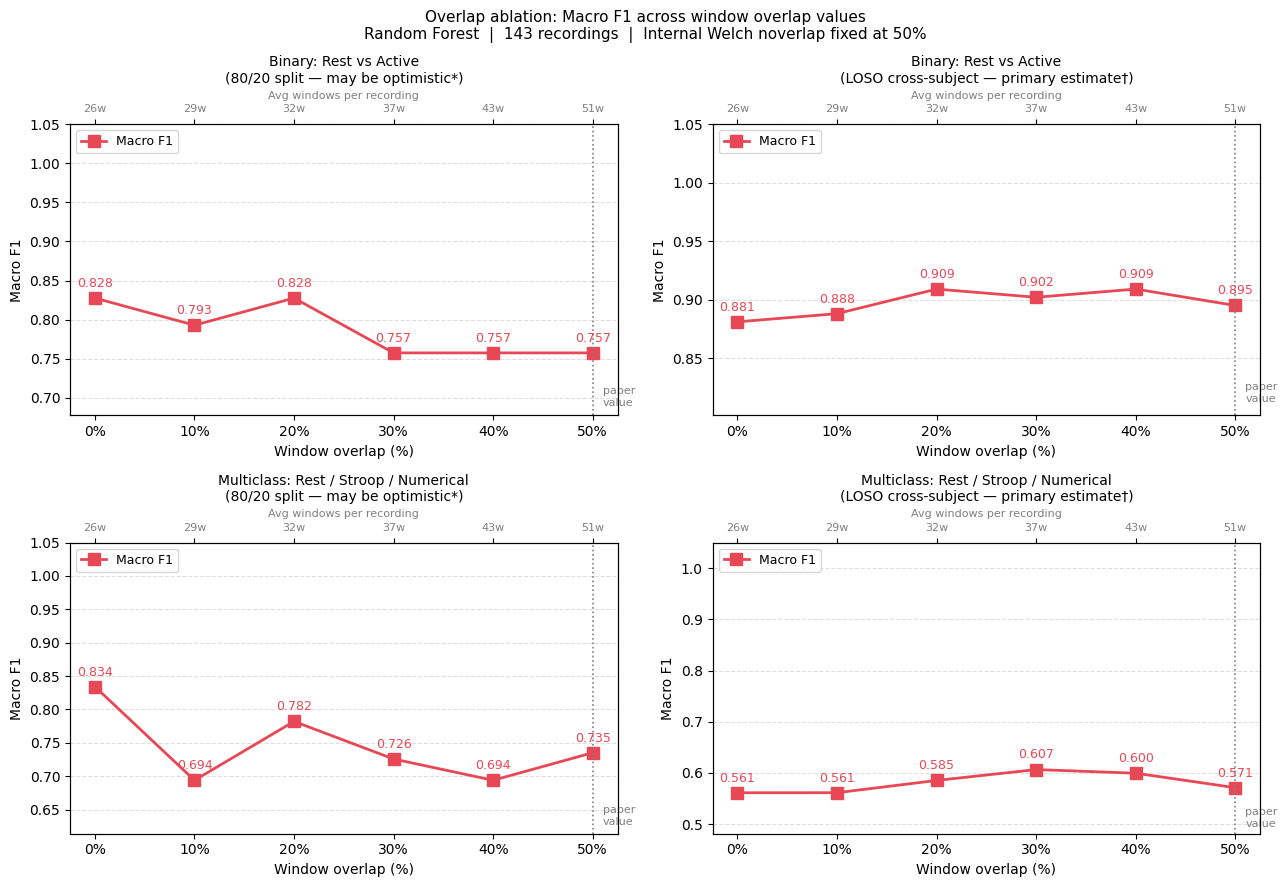

Figure saved: overlap_ablation_results.png

Results saved: overlap_ablation_results.csv

Done.


In [11]:


import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from scipy.signal import welch, coherence, butter, filtfilt
from scipy.integrate import simps
from specparam import SpectralModel

# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────────
FS          = 125
TRIM_SEC    = 10
WIN_LEN_SEC = 5
N_PERSEG    = int(WIN_LEN_SEC * FS)   # 625 samples
# Internal Welch overlap is FIXED throughout — not varied in this ablation
WELCH_NOVERLAP = N_PERSEG // 2

BASE_PATH     = "/"
CHANNEL_NAMES = ["LF-FpZ", "OTE_L-FpZ", "RF-FpZ", "OTE_R-FpZ"]

# Outer feature-window stepping overlap values to sweep
OVERLAP_VALUES = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]

# ──────────────────────────────────────────────────────────────────────────────
# EOG REGRESSION
# ──────────────────────────────────────────────────────────────────────────────
def _eog_bandpass(eog, fs=FS, low=1.0, high=4.0, order=4):
    nyq  = 0.5 * fs
    b, a = butter(order,
                  [max(low / nyq, 0.0001), min(high / nyq, 0.9999)],
                  btype="band")
    return filtfilt(b, a, eog, axis=0)


def regress_eog_basic(eeg_data, eog_signal, fs=FS):
    if eog_signal is None:
        return eeg_data
    try:
        eog_filt = _eog_bandpass(eog_signal.reshape(-1, 1), fs=fs).ravel()
    except Exception:
        return eeg_data
    eeg_clean = eeg_data.copy()
    for ch in range(eeg_clean.shape[1]):
        try:
            a = np.polyfit(eog_filt, eeg_clean[:, ch], deg=1)[0]
            eeg_clean[:, ch] -= a * eog_filt
        except Exception:
            continue
    return eeg_clean

# ──────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# ──────────────────────────────────────────────────────────────────────────────
def load_eeg_data(base_path):
    eeg_files = glob.glob(
        os.path.join(base_path, "*", "eeg", "**", "*.csv"), recursive=True
    )
    print(f"Found {len(eeg_files)} EEG files.")

    rows = []
    for file_path in eeg_files:
        rel_path = os.path.relpath(file_path, base_path)
        parts    = rel_path.split(os.sep)
        if len(parts) < 4:
            continue

        participant = parts[0]
        task_dir    = parts[2].lower()
        if task_dir not in ("rest", "numerical", "stroop"):
            continue

        filename = os.path.basename(file_path).lower()
        posture_match = re.search(r'd[123]', filename)
        if not posture_match:
            continue
        posture = posture_match.group().upper()

        try:
            df_csv = pd.read_csv(file_path)

            if "time_sec" in df_csv.columns:
                df_csv = df_csv.drop(columns=["time_sec"])

            eog_sig = None
            if "EOG" in df_csv.columns:
                eog_sig = df_csv["EOG"].values.astype(np.float32)
                df_csv  = df_csv.drop(columns=["EOG"])

            # Normalise column names cleanly — no in-expression reassignment
            if set(df_csv.columns) != set(CHANNEL_NAMES):
                if df_csv.shape[1] >= 4:
                    df_csv = df_csv.iloc[:, -4:].copy()
                    df_csv.columns = CHANNEL_NAMES
                else:
                    continue
            else:
                df_csv = df_csv[CHANNEL_NAMES]

            eeg_data = df_csv.values.astype(np.float32)

            if eog_sig is not None:
                eeg_data = regress_eog_basic(eeg_data, eog_sig, fs=FS)

        except Exception:
            continue

        rows.append({
            "participant": participant,
            "task":        task_dir,
            "posture":     posture,
            "data":        eeg_data,
        })

    return pd.DataFrame(rows)

# ──────────────────────────────────────────────────────────────────────────────
# FEATURE EXTRACTION  (internal Welch noverlap is always WELCH_NOVERLAP)
# ──────────────────────────────────────────────────────────────────────────────
def _spectral_features(sig):
    freqs, psd = welch(sig, fs=FS, nperseg=N_PERSEG, noverlap=WELCH_NOVERLAP)
    bands = {"theta": (4, 8), "alpha": (8, 13), "beta": (13, 30)}
    powers = {}
    for name, (lo, hi) in bands.items():
        m = (freqs >= lo) & (freqs <= hi)
        powers[name] = float(simps(psd[m], freqs[m]) if np.any(m) else 0.0)
    total = sum(powers.values())
    out   = {}
    for name, val in powers.items():
        out[f"{name}_power"] = val
        out[f"{name}_rel"]   = float(val / total) if total > 0 else 0.0
    th, al, be = powers["theta"], powers["alpha"], powers["beta"]
    out["theta_alpha"] = float(th / al) if al > 0 else 0.0
    out["theta_beta"]  = float(th / be) if be > 0 else 0.0
    out["alpha_beta"]  = float(al / be) if be > 0 else 0.0
    return out


def _coherence_features(ch1, ch2):
    f, coh = coherence(ch1, ch2, fs=FS, nperseg=N_PERSEG, noverlap=WELCH_NOVERLAP)
    out = {}
    for name, (lo, hi) in [("theta",(4,8)),("alpha",(8,13)),
                            ("beta",(13,30)),("overall",(4,30))]:
        m = (f >= lo) & (f <= hi)
        out[name] = float(np.mean(coh[m]) if np.any(m) else 0.0)
    return out


def _band_powers_per_channel(win):
    out = {}
    for ci in range(win.shape[1]):
        freqs, psd = welch(win[:, ci], fs=FS, nperseg=N_PERSEG,
                           noverlap=WELCH_NOVERLAP)
        for name, (lo, hi) in [("Theta",(4,8)),("Alpha",(8,13)),("Beta",(13,30))]:
            m = (freqs >= lo) & (freqs <= hi)
            out[f"Band{name}_ch{ci+1}"] = float(
                simps(psd[m], freqs[m]) if np.any(m) else 0.0
            )
    return out


def _periodic_alpha(win):
    out, vals = {}, []
    for ci in range(win.shape[1]):
        freqs, psd = welch(win[:, ci], fs=FS, nperseg=N_PERSEG,
                           noverlap=WELCH_NOVERLAP)
        model = SpectralModel(peak_width_limits=[1, 8],
                              min_peak_height=0.05, verbose=False)
        pa = 0.0
        try:
            model.fit(freqs, psd, [1, 30])
            exp    = model.get_params("aperiodic", "exponent")
            offset = model.get_params("aperiodic", "offset")
            ap_log   = offset - exp * np.log10(freqs)
            periodic = 10 ** (np.log10(psd + 1e-12) - ap_log)
            periodic[periodic < 0] = 0
            m  = (freqs >= 8) & (freqs <= 13)
            pa = float(simps(periodic[m], freqs[m]) if np.any(m) else 0.0)
        except Exception:
            pass
        out[f"PeriodicAlpha_ch{ci+1}"]     = pa
        out[f"log_PeriodicAlpha_ch{ci+1}"] = float(np.log(pa + 1e-6))
        vals.append(pa)
    pa_mean = float(np.mean(vals)) if vals else 0.0
    out["PeriodicAlpha_mean"]     = pa_mean
    out["log_PeriodicAlpha_mean"] = float(np.log(pa_mean + 1e-6))
    return out


def extract_features_with_overlap(row, overlap_frac):
    """
    Extract and AVERAGE features across all analysis windows in one recording.

    overlap_frac controls the step between successive windows:
        step = N_PERSEG * (1 - overlap_frac)
    A larger overlap_frac → smaller step → more windows → more stable average.

    The Welch/coherence noverlap inside each window is always WELCH_NOVERLAP
    (50% of N_PERSEG) regardless of overlap_frac. These are independent
    parameters and only the former is swept in this ablation.

    Returns a single dict representing ONE sample per recording.
    """
    data = row["data"]
    trim = int(TRIM_SEC * FS)
    if data.shape[0] <= 2 * trim:
        return None, 0
    seg = data[trim:-trim, :]
    if seg.shape[0] < N_PERSEG:
        return None, 0

    n_step = max(1, int(N_PERSEG * (1.0 - overlap_frac)))
    starts = np.arange(0, seg.shape[0] - N_PERSEG + 1, n_step)
    if len(starts) == 0:
        return None, 0

    window_features = []
    for start in starts:
        win = seg[start:start + N_PERSEG, :]

        spec = {}
        for i in range(win.shape[1]):
            for k, v in _spectral_features(win[:, i]).items():
                spec[f"eeg_Ch{i+1}_{k}"] = v

        coh_feat = {}
        for (i, j) in [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]:
            for band, val in _coherence_features(win[:, i], win[:, j]).items():
                coh_feat[f"coh_C{i+1}C{j+1}_{band}"] = val

        bp         = _band_powers_per_channel(win)
        ratio_feat = {}
        tbr_list, ei_list = [], []
        for ci in range(win.shape[1]):
            th  = bp.get(f"BandTheta_ch{ci+1}", 0.0)
            al  = bp.get(f"BandAlpha_ch{ci+1}", 0.0)
            be  = bp.get(f"BandBeta_ch{ci+1}",  0.0)
            tbr = (th / be)        if be > 0      else 0.0
            ei  = (be / (al + th)) if (al+th) > 0 else 0.0
            ratio_feat[f"TBR_ch{ci+1}"] = float(tbr)
            ratio_feat[f"EI_ch{ci+1}"]  = float(ei)
            tbr_list.append(tbr)
            ei_list.append(ei)
        ratio_feat["TBR_mean"] = float(np.mean(tbr_list))
        ratio_feat["EI_mean"]  = float(np.mean(ei_list))
        ratio_feat["TBR_std"]  = float(np.std(tbr_list))
        ratio_feat["EI_std"]   = float(np.std(ei_list))

        pa_feat = _periodic_alpha(win)

        window_features.append({**spec, **coh_feat, **bp, **ratio_feat, **pa_feat})

    if not window_features:
        return None, 0

    keys    = list(window_features[0].keys())
    avg     = {k: float(np.mean([wf[k] for wf in window_features])) for k in keys}
    return avg, len(window_features)


def build_dataset_for_overlap(df_eeg, overlap_frac):
    rows         = []
    total_windows = 0
    for _, row in df_eeg.iterrows():
        feat, n_win = extract_features_with_overlap(row, overlap_frac)
        if feat is None:
            continue
        total_windows += n_win
        task_raw = str(row["task"]).lower()
        task     = {"rest": "Rest", "stroop": "Stroop"}.get(task_raw, "Numerical")
        rows.append({
            "Participant": row["participant"],
            "Task":        task,
            "BinaryLabel": "Rest" if task == "Rest" else "Active",
            **feat,
        })
    return pd.DataFrame(rows), total_windows

# ──────────────────────────────────────────────────────────────────────────────
# CLASSIFIERS
# ──────────────────────────────────────────────────────────────────────────────
def fit_predict_80_20(df, target_col, balance, random_state=42):
    """
    Mirrors evaluate_global_80_20_with_outputs() from the main script exactly:
      - SMOTE check uses pandas .value_counts() on the raw y_train Series
      - SMOTE is applied AFTER scaling, before fitting
      - RF uses class_weight=None when SMOTE is used, else 'balanced' if balance=True
    NOTE: same-participant split is possible; results may be optimistic.
    LOSO is the primary reliability measure.
    """
    feat_cols = [c for c in df.columns
                 if c not in ("Participant", "Task", "BinaryLabel")]
    X, y = df[feat_cols], df[target_col]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )

    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_te_s  = scaler.transform(X_te)

    # Exactly as in main script: check on pandas Series BEFORE numpy conversion
    use_smote = False
    if balance and len(np.unique(y_tr)) == 2:
        class_counts = pd.Series(y_tr).value_counts()
        if class_counts.min() >= 2:
            use_smote = True

    if use_smote:
        X_tr_s, y_tr = SMOTE(random_state=42).fit_resample(X_tr_s, y_tr)

    clf = RandomForestClassifier(
        n_estimators=300,
        class_weight=None if use_smote else ("balanced" if balance else None),
        random_state=random_state,
    )
    clf.fit(X_tr_s, y_tr)
    y_pred = clf.predict(X_te_s)

    acc = accuracy_score(y_te, y_pred)
    f1  = precision_recall_fscore_support(
        y_te, y_pred, average="macro", zero_division=0
    )[2]
    return acc, f1


def fit_predict_loso(df, target_col, balance, class_names):
    """
    Mirrors evaluate_cross_subject_with_outputs() from the main script exactly:
      - Scaler is fit per fold on training data only (no leakage)
      - SMOTE check uses pandas .value_counts() on the pandas Series y_tr
        BEFORE scaler transform (scaler is applied to X only, y stays as Series)
      - SMOTE applied only for binary (len(class_names) == 2) balanced tasks
      - RF uses class_weight=None when SMOTE is used, else 'balanced' if balance=True
    This is the primary, cross-subject generalisation estimate.
    """
    feat_cols = [c for c in df.columns
                 if c not in ("Participant", "Task", "BinaryLabel")]
    X, y, groups = df[feat_cols], df[target_col], df["Participant"]

    logo           = LeaveOneGroupOut()
    y_true, y_pred = [], []

    for tr_idx, te_idx in logo.split(X, y, groups):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        if len(np.unique(y_tr)) < 2:
            continue

        # Scale X only — y_tr remains a pandas Series for the SMOTE check below
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        # Exactly as in main script: use len(class_names) == 2, not unique(y_tr)
        use_smote = False
        if balance and len(class_names) == 2:
            class_counts = y_tr.value_counts()   # y_tr is still a pandas Series
            if class_counts.min() >= 2:
                use_smote = True

        if use_smote:
            X_tr_s, y_tr = SMOTE(random_state=42).fit_resample(X_tr_s, y_tr)

        clf = RandomForestClassifier(
            n_estimators=300,
            class_weight=None if use_smote else ("balanced" if balance else None),
            random_state=42,
        )
        clf.fit(X_tr_s, y_tr)
        y_pred.extend(clf.predict(X_te_s))
        y_true.extend(y_te)

    acc = accuracy_score(y_true, y_pred)
    f1  = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )[2]
    return acc, f1

# ──────────────────────────────────────────────────────────────────────────────
# ABLATION LOOP
# ──────────────────────────────────────────────────────────────────────────────
def run_overlap_ablation(df_eeg):
    results = []

    for ov in OVERLAP_VALUES:
        pct    = int(ov * 100)
        n_step = max(1, int(N_PERSEG * (1.0 - ov)))
        print(f"\n{'='*65}")
        print(f"Overlap = {pct}%  (step = {n_step} samples = {n_step/FS:.2f}s per window)")
        print(f"  [Internal Welch noverlap fixed at {WELCH_NOVERLAP} samples = {WELCH_NOVERLAP/FS:.2f}s]")
        print(f"{'='*65}")

        df_feat, total_windows = build_dataset_for_overlap(df_eeg, ov)
        if df_feat.empty:
            print("  No features extracted — skipping.")
            continue

        n_recordings = len(df_feat)
        print(f"  Recordings (= ML samples): {n_recordings}")
        print(f"  Total windows averaged:    {total_windows}")
        print(f"  Avg windows per recording: {total_windows/n_recordings:.1f}")

        # Binary: Rest vs Active
        bin_80_f1  = fit_predict_80_20(df_feat, "BinaryLabel", balance=True)[1]
        bin_lo_f1  = fit_predict_loso(df_feat,  "BinaryLabel", balance=True,
                                      class_names=["Rest", "Active"])[1]

        # Multiclass: Rest vs Stroop vs Numerical
        mul_80_f1  = fit_predict_80_20(df_feat, "Task", balance=False)[1]
        mul_lo_f1  = fit_predict_loso(df_feat,  "Task", balance=False,
                                      class_names=["Rest", "Stroop", "Numerical"])[1]

        print(f"  Binary     | 80/20* F1={bin_80_f1:.3f}  | LOSO† F1={bin_lo_f1:.3f}")
        print(f"  Multiclass | 80/20* F1={mul_80_f1:.3f}  | LOSO† F1={mul_lo_f1:.3f}")
        print("  * 80/20 may be optimistic (same-participant split possible)")
        print("  † LOSO is the primary cross-subject estimate")

        results.append({
            "overlap_pct":         pct,
            "avg_windows_per_rec": round(total_windows / n_recordings, 1),
            "binary_f1_8020":      bin_80_f1,
            "binary_f1_loso":      bin_lo_f1,
            "multi_f1_8020":       mul_80_f1,
            "multi_f1_loso":       mul_lo_f1,
        })

    return pd.DataFrame(results)


# ──────────────────────────────────────────────────────────────────────────────
# PLOTTING  (2x2: binary/multiclass x 80-20/LOSO, F1 only)
# ──────────────────────────────────────────────────────────────────────────────
def plot_ablation_results(df_res):
    x      = df_res["overlap_pct"].values
    labels = [f"{v}%" for v in x]
    color  = "#E84855"   # single colour — F1 only

    configs = [
        ("binary_f1_8020", "Binary: Rest vs Active\n(80/20 split — may be optimistic*)"),
        ("binary_f1_loso", "Binary: Rest vs Active\n(LOSO cross-subject — primary estimate†)"),
        ("multi_f1_8020",  "Multiclass: Rest / Stroop / Numerical\n(80/20 split — may be optimistic*)"),
        ("multi_f1_loso",  "Multiclass: Rest / Stroop / Numerical\n(LOSO cross-subject — primary estimate†)"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(
        "Overlap ablation: Macro F1 across window overlap values\n"
        "Random Forest  |  143 recordings  |  Internal Welch noverlap fixed at 50%",
        fontsize=11
    )

    for ax, (col, title) in zip(axes.flat, configs):
        vals = df_res[col].values

        ax.plot(x, vals, "s-", color=color, lw=2, markersize=8, label="Macro F1")

        ymin = max(0, float(vals.min()) - 0.08)
        ax.set_ylim(ymin, 1.05)

        if 50 in x:
            ax.axvline(x=50, color="gray", linestyle=":", linewidth=1.2)
            ax.text(51, ymin + 0.01, "paper\nvalue", fontsize=8, color="gray", va="bottom")

        for xi, v in zip(x, vals):
            ax.annotate(f"{v:.3f}", (xi, v),
                        textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=9, color=color)

        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_xlabel("Window overlap (%)")
        ax.set_ylabel("Macro F1")
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        # Top x-axis: avg windows per recording
        ax2x = ax.twiny()
        ax2x.set_xlim(ax.get_xlim())
        ax2x.set_xticks(x)
        ax2x.set_xticklabels(
            [f"{w:.0f}w" for w in df_res["avg_windows_per_rec"]],
            fontsize=8, color="gray"
        )
        ax2x.set_xlabel("Avg windows per recording", fontsize=8, color="gray")

    plt.tight_layout()
    plt.savefig("overlap_ablation_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved: overlap_ablation_results.png")


# ──────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ──────────────────────────────────────────────────────────────────────────────
def print_summary_table(df_res):
    sep = "=" * 80
    print(f"\n{sep}")
    print("OVERLAP ABLATION SUMMARY — Macro F1 (Random Forest)")
    print("  * 80/20: same-participant split possible — may be optimistic")
    print("  † LOSO:  leave-one-subject-out — primary cross-subject estimate")
    print(sep)
    print(f"{'Overlap':>8} {'AvgWin':>7} | "
          f"{'Binary 80/20*':>14} | {'Binary LOSO†':>13} | "
          f"{'Multi 80/20*':>13} | {'Multi LOSO†':>12}")
    print("-" * 80)
    for _, row in df_res.iterrows():
        print(
            f"{int(row.overlap_pct):>7}% {row.avg_windows_per_rec:>7.1f} | "
            f"{row.binary_f1_8020:>14.3f} | "
            f"{row.binary_f1_loso:>13.3f} | "
            f"{row.multi_f1_8020:>13.3f} | "
            f"{row.multi_f1_loso:>12.3f}"
        )
    print(sep)
    print("\nWhat to look for:")
    print("  Flat LOSO curves → 50% overlap is a stability choice, not a leakage source.")
    print("  More AvgWin = lower variance in averaged features.")
    print("  80/20 > LOSO gap = participant-level dependency, not overlap leakage.")


# ──────────────────────────────────────────────────────────────────────────────
# MAIN
# ──────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Overlap Ablation — Binary + Multiclass (Macro F1 only)")
    print(f"Sweeping overlap: {[f'{int(v*100)}%' for v in OVERLAP_VALUES]}")
    print(f"Internal Welch noverlap: fixed at {WELCH_NOVERLAP} samples ({WELCH_NOVERLAP/FS:.2f}s)\n")

    df_eeg = load_eeg_data(BASE_PATH)
    if df_eeg.empty:
        print("No valid EEG data found.")
        raise SystemExit

    print(f"Loaded {len(df_eeg)} recordings from {df_eeg['participant'].nunique()} participants")

    df_results = run_overlap_ablation(df_eeg)

    print_summary_table(df_results)
    plot_ablation_results(df_results)

    df_results.to_csv("overlap_ablation_results.csv", index=False)
    print("\nResults saved: overlap_ablation_results.csv")
    print("\nDone.")

<H1>EEG GRID SEARCH -MOBILEHCI </h1>

In [33]:
from pathlib import Path
import os
import glob
import re
import numpy as np
import pandas as pd
from itertools import product

from scipy.signal import welch, coherence, butter, filtfilt
from scipy.integrate import simps
from specparam import SpectralModel

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import warnings
warnings.filterwarnings("ignore")

# ================= CONFIG =================
FS            = 125
TRIM_SEC      = 10
WIN_LEN_SEC   = 5
N_PERSEG      = int(WIN_LEN_SEC * FS)
WIN_STEP_SEC  = WIN_LEN_SEC / 2
N_STEP        = int(WIN_STEP_SEC * FS)
N_OVERLAP     = N_PERSEG // 2

BASE_PATH     = "/Users/sgomasta/Desktop/Tech Neck Coding/derived(nobl)/"
CHANNEL_NAMES = ["LF-FpZ", "OTE_L-FpZ", "RF-FpZ", "OTE_R-FpZ"]

# ================= EOG HELPERS =================
def _eog_bandpass(eog, fs=FS, low=1.0, high=4.0, order=4):
    nyq    = 0.5 * fs
    low_n  = max(low  / nyq, 0.0001)
    high_n = min(high / nyq, 0.9999)
    b, a   = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, eog, axis=0)


def regress_eog_basic(eeg_data, eog_signal, fs=FS):
    if eog_signal is None:
        return eeg_data
    try:
        eog_filt = _eog_bandpass(eog_signal.reshape(-1, 1), fs=fs).ravel()
    except Exception:
        return eeg_data
    eeg_clean = eeg_data.copy()
    for ch in range(eeg_clean.shape[1]):
        try:
            a = np.polyfit(eog_filt, eeg_clean[:, ch], deg=1)[0]
            eeg_clean[:, ch] -= a * eog_filt
        except Exception:
            continue
    return eeg_clean


# ================= DATA LOADING =================
def load_eeg_data(base_path):
    eeg_files = glob.glob(
        os.path.join(base_path, "*", "eeg", "**", "*.csv"),
        recursive=True
    )
    print(f"EEG files found: {len(eeg_files)}")

    rows = []
    for file_path in eeg_files:
        rel_path = os.path.relpath(file_path, base_path)
        parts    = rel_path.split(os.sep)
        if len(parts) < 4:
            continue

        participant = parts[0]
        task_dir    = parts[2].lower()

        if task_dir == "rest":
            task = "rest"
        elif task_dir == "numerical":
            task = "numerical"
        elif task_dir == "stroop":
            task = "stroop"
        else:
            continue

        filename      = os.path.basename(file_path).lower()
        posture_match = re.search(r'd[123]', filename)
        if not posture_match:
            continue
        posture = posture_match.group().upper()

        try:
            df_csv = pd.read_csv(file_path)

            if "time_sec" in df_csv.columns:
                df_csv = df_csv.drop(columns=["time_sec"])

            eog_sig = None
            if "EOG" in df_csv.columns:
                eog_sig = df_csv["EOG"].values.astype(np.float32)
                df_csv  = df_csv.drop(columns=["EOG"])

            if set(df_csv.columns) != set(CHANNEL_NAMES):
                if df_csv.shape[1] >= 4:
                    df_csv         = df_csv.iloc[:, -4:]
                    df_csv.columns = CHANNEL_NAMES
                else:
                    continue
            else:
                df_csv = df_csv[CHANNEL_NAMES]

            eeg_data = df_csv.values.astype(np.float32)

            if eog_sig is not None:
                eeg_data = regress_eog_basic(eeg_data, eog_sig, fs=FS)

        except Exception:
            continue

        rows.append({
            "participant": participant,
            "task":        task,
            "posture":     posture,
            "data":        eeg_data,
        })

    return pd.DataFrame(rows)


# ================= FEATURE EXTRACTION =================
def extract_spectral_features_from_window(sig, fs=FS):
    freqs, psd = welch(sig, fs=fs, nperseg=N_PERSEG, noverlap=N_OVERLAP)

    theta_m = (freqs >= 4)  & (freqs <= 8)
    alpha_m = (freqs >= 8)  & (freqs <= 13)
    beta_m  = (freqs >= 13) & (freqs <= 30)

    theta_p = simps(psd[theta_m], freqs[theta_m]) if np.any(theta_m) else 0.0
    alpha_p = simps(psd[alpha_m], freqs[alpha_m]) if np.any(alpha_m) else 0.0
    beta_p  = simps(psd[beta_m],  freqs[beta_m])  if np.any(beta_m)  else 0.0

    total     = theta_p + alpha_p + beta_p
    theta_rel = theta_p / total if total > 0 else 0.0
    alpha_rel = alpha_p / total if total > 0 else 0.0
    beta_rel  = beta_p  / total if total > 0 else 0.0

    return {
        "Theta_power":       float(theta_p),
        "Alpha_power":       float(alpha_p),
        "Beta_power":        float(beta_p),
        "Theta_rel_power":   float(theta_rel),
        "Alpha_rel_power":   float(alpha_rel),
        "Beta_rel_power":    float(beta_rel),
        "theta_alpha_ratio": float(theta_p / alpha_p if alpha_p > 0 else 0.0),
        "theta_beta_ratio":  float(theta_p / beta_p  if beta_p  > 0 else 0.0),
        "alpha_beta_ratio":  float(alpha_p / beta_p  if beta_p  > 0 else 0.0),
    }


def extract_coherence_from_window(ch1, ch2, fs=FS):
    f, coh  = coherence(ch1, ch2, fs=fs, nperseg=N_PERSEG, noverlap=N_OVERLAP)
    theta_c = np.mean(coh[(f >= 4)  & (f <= 8)])  if np.any((f >= 4)  & (f <= 8))  else 0.0
    alpha_c = np.mean(coh[(f >= 8)  & (f <= 13)]) if np.any((f >= 8)  & (f <= 13)) else 0.0
    beta_c  = np.mean(coh[(f >= 13) & (f <= 30)]) if np.any((f >= 13) & (f <= 30)) else 0.0
    overall = np.mean(coh[(f >= 4)  & (f <= 30)]) if np.any((f >= 4)  & (f <= 30)) else 0.0
    return {
        "Theta":   float(theta_c),
        "Alpha":   float(alpha_c),
        "Beta":    float(beta_c),
        "overall": float(overall),
    }


def extract_band_powers_per_channel(window_data, fs=FS):
    out  = {}
    n_ch = window_data.shape[1]
    for ci in range(n_ch):
        freqs, psd = welch(window_data[:, ci], fs=fs, nperseg=N_PERSEG, noverlap=N_OVERLAP)
        m_t = (freqs >= 4)  & (freqs <= 8)
        m_a = (freqs >= 8)  & (freqs <= 13)
        m_b = (freqs >= 13) & (freqs <= 30)
        out[f"BandTheta_ch{ci+1}"] = float(simps(psd[m_t], freqs[m_t]) if np.any(m_t) else 0.0)
        out[f"BandAlpha_ch{ci+1}"] = float(simps(psd[m_a], freqs[m_a]) if np.any(m_a) else 0.0)
        out[f"BandBeta_ch{ci+1}"]  = float(simps(psd[m_b], freqs[m_b]) if np.any(m_b) else 0.0)
    return out


def extract_periodic_alpha_per_channel(window_data, fs=FS):
    out           = {}
    periodic_vals = []
    n_ch          = window_data.shape[1]

    for ci in range(n_ch):
        freqs, psd = welch(window_data[:, ci], fs=fs, nperseg=N_PERSEG, noverlap=N_OVERLAP)
        model = SpectralModel(peak_width_limits=[1, 8], min_peak_height=0.05, verbose=False)
        pa    = 0.0
        try:
            model.fit(freqs, psd, [1, 30])
            exp        = model.get_params("aperiodic", "exponent")
            offset     = model.get_params("aperiodic", "offset")
            ap_fit_log = offset - exp * np.log10(freqs)
            psd_log    = np.log10(psd + 1e-12)
            periodic   = 10 ** (psd_log - ap_fit_log)
            periodic[periodic < 0] = 0
            mask = (freqs >= 8) & (freqs <= 13)
            if np.any(mask):
                pa = float(simps(periodic[mask], freqs[mask]))
        except Exception:
            pa = 0.0

        out[f"PeriodicAlpha_ch{ci+1}"]     = pa
        out[f"log_PeriodicAlpha_ch{ci+1}"] = float(np.log(pa + 1e-6))
        periodic_vals.append(pa)

    pa_mean = float(np.mean(periodic_vals)) if periodic_vals else 0.0
    out["PeriodicAlpha_mean"]     = pa_mean
    out["log_PeriodicAlpha_mean"] = float(np.log(pa_mean + 1e-6))
    return out


def extract_features_per_segment(row):
    data = row["data"]
    trim = int(TRIM_SEC * FS)
    if data.shape[0] <= 2 * trim:
        return None

    seg = data[trim:-trim, :]
    if seg.shape[0] < N_PERSEG:
        return None

    starts = np.arange(0, seg.shape[0] - N_PERSEG + 1, N_STEP)
    if len(starts) == 0:
        return None

    window_features = []
    for start in starts:
        win_data = seg[start:start + N_PERSEG, :]

        spec_feat = {}
        for i in range(win_data.shape[1]):
            feats = extract_spectral_features_from_window(win_data[:, i])
            for k, v in feats.items():
                spec_feat[f"eeg_Channel_{i+1}_{k}"] = v

        coh_feat = {}
        for (i, j) in [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]:
            coh = extract_coherence_from_window(win_data[:, i], win_data[:, j])
            for band, val in coh.items():
                coh_feat[f"eeg_coherence_C{i+1}_C{j+1}_{band}"] = val

        bp         = extract_band_powers_per_channel(win_data)
        ratio_feat = {}
        tbr_list   = []
        ei_list    = []

        for ci in range(win_data.shape[1]):
            th  = bp.get(f"BandTheta_ch{ci+1}", 0.0)
            al  = bp.get(f"BandAlpha_ch{ci+1}", 0.0)
            be  = bp.get(f"BandBeta_ch{ci+1}",  0.0)
            tbr = (th / be)        if be        > 0 else 0.0
            ei  = (be / (al + th)) if (al + th) > 0 else 0.0
            ratio_feat[f"TBR_ch{ci+1}"]              = float(tbr)
            ratio_feat[f"EngagementIndex_ch{ci+1}"]  = float(ei)
            tbr_list.append(tbr)
            ei_list.append(ei)

        ratio_feat["TBR_mean"]             = float(np.mean(tbr_list)) if tbr_list else 0.0
        ratio_feat["EngagementIndex_mean"] = float(np.mean(ei_list))  if ei_list  else 0.0
        ratio_feat["TBR_std"]              = float(np.std(tbr_list))  if tbr_list else 0.0
        ratio_feat["EngagementIndex_std"]  = float(np.std(ei_list))   if ei_list  else 0.0

        pa_feat = extract_periodic_alpha_per_channel(win_data)

        window_features.append({**spec_feat, **coh_feat, **bp, **ratio_feat, **pa_feat})

    if not window_features:
        return None

    keys     = list(window_features[0].keys())
    avg_feat = {k: float(np.mean([wf[k] for wf in window_features])) for k in keys}
    return avg_feat


def build_dataset(df_eeg):
    rows = []
    for _, row in df_eeg.iterrows():
        feat = extract_features_per_segment(row)
        if feat is None:
            continue
        task_raw = str(row["task"]).lower()
        task = {"rest": "Rest", "stroop": "Stroop"}.get(task_raw, "Numerical")
        rows.append({
            "Participant": row["participant"],
            "Task":        task,
            "BinaryLabel": "Rest" if task == "Rest" else "Active",
            **feat,
        })
    return pd.DataFrame(rows)


# ================= LOSO EVALUATION =================
def evaluate_pipeline(pipeline, X, y, groups):
    """
    Manual LOSO so scaler is fit only on training folds.
    Always uses average='macro' so string labels work correctly
    for both binary (Rest/Active) and multiclass (Rest/Stroop/Numerical).
    Returns accuracy, precision, recall, f1.
    """
    logo       = LeaveOneGroupOut()
    y_true_all = []
    y_pred_all = []
    n_classes  = len(np.unique(y))

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # skip fold if a class is missing from training
        if len(np.unique(y_tr)) < n_classes:
            continue

        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_te)

        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    # always use macro — works for both string-label binary and multiclass
    acc  = accuracy_score(y_true_all,  y_pred_all)
    f1   = f1_score(y_true_all,        y_pred_all, average="macro", zero_division=0)
    prec = precision_score(y_true_all,  y_pred_all, average="macro", zero_division=0)
    rec  = recall_score(y_true_all,     y_pred_all, average="macro", zero_division=0)

    return acc, prec, rec, f1


# ================= GRID SEARCH =================
def run_grid(model_name, param_grid, clf_constructor, clf_fixed_kwargs,
             X, y, groups, task_label, all_results):
    keys   = list(param_grid.keys())
    combos = list(product(*param_grid.values()))
    print(f"\n  {model_name} [{task_label}]: {len(combos)} combinations")

    for combo in combos:
        tunable    = dict(zip(keys, combo))
        all_kwargs = {**tunable, **clf_fixed_kwargs}

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    clf_constructor(**all_kwargs)),
        ])

        acc, prec, rec, f1 = evaluate_pipeline(pipeline, X, y, groups)

        param_str = "  ".join(f"{k}={v}" for k, v in tunable.items())
        print(
            f"    {param_str} | "
            f"Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}"
        )

        all_results.append({
            "model":     model_name,
            "task":      task_label,
            **tunable,
            "accuracy":  round(acc,  4),
            "precision": round(prec, 4),
            "recall":    round(rec,  4),
            "f1":        round(f1,   4),
        })


# ================= SUMMARY =================
def print_summary(df_results):
    skip_cols = {"model", "task", "accuracy", "precision", "recall", "f1"}
    print("\n" + "=" * 70)
    print("BEST CONFIG PER MODEL + TASK  (ranked by F1)")
    print("=" * 70)

    for task_label in ["binary", "multiclass"]:
        print(f"\n--- {task_label.upper()} ---")
        for model_name in ["GB", "RF", "RBF_SVM", "LinearSVM"]:
            subset = df_results[
                (df_results["model"] == model_name) &
                (df_results["task"]  == task_label)
            ]
            if subset.empty:
                continue
            best      = subset.loc[subset["f1"].idxmax()]
            param_str = ", ".join(
                f"{c}={best[c]}"
                for c in best.index
                if c not in skip_cols and pd.notna(best[c])
            )
            print(
                f"  {model_name:12s} | "
                f"Acc={best['accuracy']:.3f}  "
                f"Prec={best['precision']:.3f}  "
                f"Rec={best['recall']:.3f}  "
                f"F1={best['f1']:.3f}  "
                f"[{param_str}]"
            )


# ================= MAIN =================
def main():
    # --- 1. Load ---
    df_eeg = load_eeg_data(BASE_PATH)
    if df_eeg.empty:
        print("No valid EEG data found. Check your data path.")
        return

    print(f"Loaded {len(df_eeg)} segments from "
          f"{df_eeg['participant'].nunique()} participants")

    # --- 2. Build features ---
    df_features = build_dataset(df_eeg)
    print(f"Extracted features for {len(df_features)} segments")

    if df_features.empty:
        print("Feature dataframe is empty. Exiting.")
        return

    # --- 3. Prepare arrays ---
    feature_cols = [
        c for c in df_features.columns
        if c not in ["Participant", "Task", "BinaryLabel"]
    ]
    X       = df_features[feature_cols].values
    y_bin   = df_features["BinaryLabel"].values   # "Rest" or "Active"  (strings)
    y_multi = df_features["Task"].values          # "Rest"/"Stroop"/"Numerical" (strings)
    groups  = df_features["Participant"].values

    all_results = []

    # ---------------------------------------------------------------
    # GB
    # ---------------------------------------------------------------
    print("\n" + "=" * 60)
    print("GB GRID SEARCH")
    print("=" * 60)
    gb_grid = {
        "n_estimators":  [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth":     [2, 3, 5],
    }
    gb_fixed = {"random_state": 42}

    for task_label, y in [("binary", y_bin), ("multiclass", y_multi)]:
        run_grid("GB", gb_grid, GradientBoostingClassifier,
                 gb_fixed, X, y, groups, task_label, all_results)

    # ---------------------------------------------------------------
    # RF
    # ---------------------------------------------------------------
    print("\n" + "=" * 60)
    print("RF GRID SEARCH")
    print("=" * 60)
    rf_grid = {
        "n_estimators":     [100, 200, 300, 500],
        "max_depth":        [5, 8, 10, None],
        "min_samples_leaf": [1, 3, 5, 8],
    }
    rf_fixed = {
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs":       -1,
    }

    for task_label, y in [("binary", y_bin), ("multiclass", y_multi)]:
        run_grid("RF", rf_grid, RandomForestClassifier,
                 rf_fixed, X, y, groups, task_label, all_results)

    # ---------------------------------------------------------------
    # RBF SVM
    # ---------------------------------------------------------------
    print("\n" + "=" * 60)
    print("RBF SVM GRID SEARCH")
    print("=" * 60)
    rbf_grid = {
        "C":     [0.1, 1.0, 10.0],
        "gamma": ["scale", "auto", 0.01],
    }
    rbf_fixed = {
        "kernel":       "rbf",
        "class_weight": "balanced",
        "random_state": 42,
    }

    for task_label, y in [("binary", y_bin), ("multiclass", y_multi)]:
        run_grid("RBF_SVM", rbf_grid, SVC,
                 rbf_fixed, X, y, groups, task_label, all_results)

    # ---------------------------------------------------------------
    # Linear SVM — matches paper: kernel=linear, C=1.0, class_weight=balanced
    # ---------------------------------------------------------------
    print("\n" + "=" * 60)
    print("LINEAR SVM GRID SEARCH")
    print("=" * 60)
    linear_grid = {
        "C": [0.01, 0.1, 1.0, 10.0],
    }
    linear_fixed = {
        "kernel":       "linear",
        "class_weight": "balanced",
        "random_state": 42,
    }

    for task_label, y in [("binary", y_bin), ("multiclass", y_multi)]:
        run_grid("LinearSVM", linear_grid, SVC,
                 linear_fixed, X, y, groups, task_label, all_results)

    # --- 4. Save + summarise ---
    df_results = pd.DataFrame(all_results)
    df_results.to_csv("eeg_grid_search_results.csv", index=False)
    print("\nFull results saved to eeg_grid_search_results.csv")

    print_summary(df_results)


if __name__ == "__main__":
    main()

EEG files found: 143
Loaded 143 segments from 24 participants
Extracted features for 143 segments

GB GRID SEARCH

  GB [binary]: 36 combinations
    n_estimators=100  learning_rate=0.01  max_depth=2 | Acc=0.860  Prec=0.863  Rec=0.860  F1=0.860
    n_estimators=100  learning_rate=0.01  max_depth=3 | Acc=0.881  Prec=0.881  Rec=0.881  F1=0.881
    n_estimators=100  learning_rate=0.01  max_depth=5 | Acc=0.818  Prec=0.818  Rec=0.818  F1=0.818
    n_estimators=100  learning_rate=0.05  max_depth=2 | Acc=0.888  Prec=0.888  Rec=0.888  F1=0.888
    n_estimators=100  learning_rate=0.05  max_depth=3 | Acc=0.874  Prec=0.874  Rec=0.874  F1=0.874
    n_estimators=100  learning_rate=0.05  max_depth=5 | Acc=0.818  Prec=0.818  Rec=0.818  F1=0.818
    n_estimators=100  learning_rate=0.1  max_depth=2 | Acc=0.895  Prec=0.895  Rec=0.895  F1=0.895
    n_estimators=100  learning_rate=0.1  max_depth=3 | Acc=0.881  Prec=0.881  Rec=0.881  F1=0.881
    n_estimators=100  learning_rate=0.1  max_depth=5 | Acc=0.811

<h1>Feature Importance Values </h1?

In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler


In [17]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, LeaveOneGroupOut

def print_top_features_8020_and_loso(
    df_features,
    target_col,
    class_names,
    task_name,
    top_k=5,
    use_xgb=True
):
    feature_cols = [c for c in df_features.columns if c not in ["Participant", "Task", "BinaryLabel"]]
    X = df_features[feature_cols]
    y = df_features[target_col]
    groups = df_features["Participant"]

    print(f"\n{'='*70}")
    print(f"TOP {top_k} FEATURES | {task_name}")
    print(f"{'='*70}")

    # =====================================================
    # 1) STRATIFIED 80/20
    # =====================================================
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)

    print("\n--- Stratified 80/20 ---")

    # RF
    rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
    rf.fit(X_tr_s, y_tr)
    rf_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(top_k)

    print("\nRF – Top Features:")
    for f, v in rf_imp.items():
        print(f"  {f:<30s} {v:.4f}")

    # GB
    gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42)
    gb.fit(X_tr_s, y_tr)
    gb_imp = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=False).head(top_k)

    print("\nGB – Top Features:")
    for f, v in gb_imp.items():
        print(f"  {f:<30s} {v:.4f}")

    # XGB (optional, encoded labels)
    if use_xgb:
        try:
            from xgboost import XGBClassifier

            classes = np.unique(y_tr)
            y_tr_enc = np.array([np.where(classes == v)[0][0] for v in y_tr])

            obj = "binary:logistic" if len(classes) == 2 else "multi:softmax"

            xgb = XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective=obj,
                num_class=len(classes) if len(classes) > 2 else None,
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
            xgb.fit(X_tr_s, y_tr_enc)

            xgb_imp = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False).head(top_k)

            print("\nXGB – Top Features:")
            for f, v in xgb_imp.items():
                print(f"  {f:<30s} {v:.4f}")

        except Exception as e:
            print(f"\nXGB skipped: {e}")

    print("\nSVM: feature importance not directly available (RBF kernel)")

 
    print("\n--- LOSO (Averaged across subjects) ---")

    logo = LeaveOneGroupOut()
    rf_imps, gb_imps, xgb_imps = [], [], []

    for tr_idx, te_idx in logo.split(X, y, groups):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]

        if len(np.unique(y_tr)) < 2:
            continue

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)

        # RF
        rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
        rf.fit(X_tr_s, y_tr)
        rf_imps.append(rf.feature_importances_)

        # GB
        gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42)
        gb.fit(X_tr_s, y_tr)
        gb_imps.append(gb.feature_importances_)

        # XGB
        if use_xgb:
            try:
                from xgboost import XGBClassifier
                classes = np.unique(y_tr)
                y_tr_enc = np.array([np.where(classes == v)[0][0] for v in y_tr])

                obj = "binary:logistic" if len(classes) == 2 else "multi:softmax"

                xgb = XGBClassifier(
                    n_estimators=300,
                    max_depth=4,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective=obj,
                    num_class=len(classes) if len(classes) > 2 else None,
                    tree_method="hist",
                    random_state=42,
                    n_jobs=-1
                )
                xgb.fit(X_tr_s, y_tr_enc)
                xgb_imps.append(xgb.feature_importances_)
            except Exception:
                pass

    def print_avg_importance(imps, name):
        if len(imps) == 0:
            return
        avg_imp = np.mean(np.vstack(imps), axis=0)
        top = pd.Series(avg_imp, index=feature_cols).sort_values(ascending=False).head(top_k)
        print(f"\n{name} – Top Features (LOSO avg):")
        for f, v in top.items():
            print(f"  {f:<30s} {v:.4f}")

    print_avg_importance(rf_imps, "RF")
    print_avg_importance(gb_imps, "GB")
    print_avg_importance(xgb_imps, "XGB")

    print("\nSVM: feature importance not directly available (RBF kernel)")


In [19]:
print_top_features_8020_and_loso(
    df_features=df_features,
    target_col="BinaryLabel",
    class_names=["Rest", "Active"],
    task_name="EEG Binary (Rest vs Active)",
    top_k=5
)

print_top_features_8020_and_loso(
    df_features=df_features,
    target_col="Task",
    class_names=["Rest", "Stroop", "Numerical"],
    task_name="EEG Multiclass (Rest vs Stroop vs Numerical)",
    top_k=5
)



TOP 5 FEATURES | EEG Binary (Rest vs Active)

--- Stratified 80/20 ---

RF – Top Features:
  eeg_Channel_4_theta_beta_ratio 0.0902
  TBR_ch4                        0.0825
  TBR_mean                       0.0669
  eeg_Channel_4_Theta_rel_power  0.0616
  eeg_Channel_4_Beta_rel_power   0.0453

GB – Top Features:
  eeg_Channel_4_Theta_rel_power  0.4712
  BandAlpha_ch1                  0.0675
  TBR_ch4                        0.0636
  eeg_Channel_4_theta_beta_ratio 0.0497
  eeg_Channel_1_Alpha_power      0.0484

XGB – Top Features:
  BandAlpha_ch3                  0.0940
  eeg_Channel_2_Alpha_rel_power  0.0733
  TBR_mean                       0.0723
  eeg_Channel_4_theta_beta_ratio 0.0671
  eeg_Channel_2_Theta_rel_power  0.0643

SVM: feature importance not directly available (RBF kernel)

--- LOSO (Averaged across subjects) ---

RF – Top Features (LOSO avg):
  eeg_Channel_4_theta_beta_ratio 0.0728
  TBR_ch4                        0.0602
  TBR_mean                       0.0585
  eeg_Channel_